# 01  Ultra-rare, length-normalized regulatory variance predicts gene constraint and purifying selection

Here we are introducing new AF metrices that we added 


## Variant Count Metrics

### **n_variants**
- **Type:** Integer
- **Description:** Total number of unique variants in this gene
- **Calculation:** Count of unique variant_id after deduplication by highest absolute effect

### **n_variants_common**
- **Type:** Integer
- **Description:** Number of common variants (AF ≥ 0.05)
- **Calculation:** Count where AF ≥ 0.05

### **n_variants_rare**
- **Type:** Integer
- **Description:** Number of rare variants (AF < 0.05)
- **Calculation:** Count where AF < 0.05

### **n_variants_common_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF ≥ 0.05
- **Calculation:** Count where perm_AF ≥ 0.05
- **Note:** Only present when permuted AFs are available

### **n_variants_rare_perm**
- **Type:** Integer
- **Description:** Number of variants with permuted AF < 0.05
- **Calculation:** Count where perm_AF < 0.05
- **Note:** Only present when permuted AFs are available

### **variants_per_kb**
- **Type:** Float
- **Description:** Variant density normalized by genomic length
- **Calculation:** n_variants / (genomic_length / 1000)

## Genetic Variance (Vg) Metrics

### **vg_predicted**
- **Type:** Float
- **Description:** Total predicted genetic variance for this gene
- **Formula:** Σ[2 × AF × (1 - AF) × β²] across all variants
- **Note:** Primary Vg metric using observed allele frequencies

### **vg_predicted_perm**
- **Type:** Float
- **Description:** Total predicted genetic variance using permuted allele frequencies
- **Formula:** Σ[2 × perm_AF × (1 - perm_AF) × β²]
- **Note:** Used as null expectation for selection analyses

### **vg_common**
- **Type:** Float
- **Description:** Genetic variance contribution from common variants (AF ≥ 0.05)
- **Calculation:** Sum of vg_contribution where AF ≥ 0.05

### **vg_rare**
- **Type:** Float
- **Description:** Genetic variance contribution from rare variants (AF < 0.05)
- **Calculation:** Sum of vg_contribution where AF < 0.05

### **vg_common_perm**
- **Type:** Float
- **Description:** Genetic variance from common variants using permuted AFs
- **Note:** Only present when permuted AFs are available

### **vg_rare_perm**
- **Type:** Float
- **Description:** Genetic variance from rare variants using permuted AFs
- **Note:** Only present when permuted AFs are available


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/markus/in-silico-vg-analysis


In [3]:
from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    DISPLAY_NAMES,
    DISPLAY_NAMES_SHORT,
)
from utils.plot_utils import save_plot, autosave

NOTEBOOK_NAME = '02_Promoter_exploring'

print('\nDatasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {GENE_PATHS[name].name}')


Datasets:
  clingen: ClinGen_HI_Gnomad_genes_21022026.parquet
  clingen_null: ClinGen_HI_Synth_genes_21022026.parquet
  background: Background_Gnomad_genes_21022026.parquet
  background_null: Background_Synth_genes_21022026.parquet


In [4]:
real_gene_dfs = []
synth_gene_dfs = []

for key, path in GENE_PATHS.items():
    lf = pl.scan_parquet(path).with_columns(pl.lit(key).alias('source'))
    if 'null' in key:
        synth_gene_dfs.append(lf)
    else:
        real_gene_dfs.append(lf)

df_real = pl.concat(real_gene_dfs).collect()
df_synth = pl.concat(synth_gene_dfs).collect()

df_hi = df_real.filter(pl.col('source') == 'clingen')
df_bg = df_real.filter(pl.col('source') == 'background')
df_hi_synth = df_synth.filter(pl.col('source') == 'clingen_null')
df_bg_synth = df_synth.filter(pl.col('source') == 'background_null')

print(f'ClinGen HI: {df_hi.height} genes')
print(f'Background: {df_bg.height} genes')
print(f'ClinGen HI (Synth): {df_hi_synth.height} genes')
print(f'Background (Synth): {df_bg_synth.height} genes')

ClinGen HI: 316 genes
Background: 349 genes
ClinGen HI (Synth): 316 genes
Background (Synth): 349 genes


In [5]:
print('df_real columns:', sorted(df_real.columns))
print('df_synth columns:', sorted(df_synth.columns))

candidate_cols = [
    c for c in df_real.columns
    if any(k in c.lower() for k in ['af', 'vg', 'promoter', 'upstream', 'downstream', 'tss', 'region'])
]
print('\nCandidate columns in df_real:')
for c in sorted(candidate_cols):
    print(' ', c)

for col in ['vg_predicted', 'vg_common', 'vg_rare', 'n_variants_common', 'n_variants_rare']:
    if col in df_real.columns:
        print(f"\n{col} summary:")
        print(
            df_real.select(
                pl.col(col).drop_nans().drop_nulls().alias(col)
            ).to_pandas()[col].describe(percentiles=[0.25, 0.5, 0.75])
        )

df_real columns: ['Episcore', 'N85', 'N90', 'RVIS_score', 'af_gradient', 'chrom', 'coding_length', 'cv_effect_N90', 'depletion_common', 'depletion_distal_upstream', 'depletion_down_distal', 'depletion_down_proximal', 'depletion_high_impact', 'depletion_promoter_core', 'depletion_proximal_upstream', 'depletion_rare', 'enrich_vg_distal_upstream', 'enrich_vg_down_distal', 'enrich_vg_down_proximal', 'enrich_vg_promoter_core', 'enrich_vg_proximal_upstream', 'entropy_distal_upstream', 'entropy_down_distal', 'entropy_down_proximal', 'entropy_effect', 'entropy_promoter_core', 'entropy_proximal_upstream', 'exonic_length', 'frac_high_impact_05', 'frac_high_impact_10', 'gene_id', 'gene_symbol', 'gene_type', 'genomic_length', 'intronic_length', 'is_mane', 'loeuf_score', 'mane_transcript_id', 'max_abs_effect', 'max_dist_to_tss', 'max_variant_id', 'max_variant_score', 'mean_abs_distal_upstream', 'mean_abs_down_distal', 'mean_abs_down_proximal', 'mean_abs_effect', 'mean_abs_promoter_core', 'mean_abs_

In [6]:
NOTEBOOK_NAME = '01_AF_cutoff_distribution'

SOURCE_ORDER = ['background', 'background_null', 'clingen', 'clingen_null']
PLOT_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'clingen_null': 'ClinGen_HI_Synth',
    'background': 'Background_Gnomad',
    'background_null': 'Background_Synth',
}

palette = {
    'background': SOURCE_PALETTE['background'],
    'background_null': SOURCE_PALETTE['background_null'],
    'clingen': SOURCE_PALETTE['clingen'],
    'clingen_null': SOURCE_PALETTE['clingen_null'],
}

REGION_COLS = {
    'promoter_core': 'Promoter (TSS±200bp)',
    'proximal_upstream': 'Proximal upstream (-200 bp to -2 kb)',
    'distal_upstream': 'Distal upstream (-2 kb to -10 kb)',
    'down_proximal': 'Proximal downstream (+200 bp to +2 kb)',
    'down_distal': 'Distal downstream (+2 kb to +10 kb)',
}

required_cols = [
    'source', 'gene_symbol',
    'vg_predicted', 'vg_predicted_perm',
    'vg_common', 'vg_common_perm',
    'vg_rare', 'vg_rare_perm',
    'n_variants_common', 'n_variants_rare', 'variants_per_kb',
    'vg_promoter_core', 'vg_promoter_core_perm',
    'vg_proximal_upstream', 'vg_proximal_upstream_perm',
    'vg_distal_upstream', 'vg_distal_upstream_perm',
    'vg_down_proximal', 'vg_down_proximal_perm',
    'vg_down_distal', 'vg_down_distal_perm',
]

all_genes = pl.concat([df_real, df_synth], how='diagonal_relaxed')
missing_cols = [c for c in required_cols if c not in all_genes.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

is_synth = pl.col('source').str.contains('null')

plot_df = (
    all_genes
    .select(required_cols)
    .with_columns([
        pl.when(is_synth).then(pl.col('vg_predicted_perm')).otherwise(pl.col('vg_predicted')).alias('vg_total_for_plot'),
        pl.when(is_synth).then(pl.col('vg_common_perm')).otherwise(pl.col('vg_common')).alias('vg_common_for_plot'),
        pl.when(is_synth).then(pl.col('vg_rare_perm')).otherwise(pl.col('vg_rare')).alias('vg_rare_for_plot'),
        pl.when(is_synth).then(pl.col('vg_promoter_core_perm')).otherwise(pl.col('vg_promoter_core')).alias('vg_region_promoter_core'),
        pl.when(is_synth).then(pl.col('vg_proximal_upstream_perm')).otherwise(pl.col('vg_proximal_upstream')).alias('vg_region_proximal_upstream'),
        pl.when(is_synth).then(pl.col('vg_distal_upstream_perm')).otherwise(pl.col('vg_distal_upstream')).alias('vg_region_distal_upstream'),
        pl.when(is_synth).then(pl.col('vg_down_proximal_perm')).otherwise(pl.col('vg_down_proximal')).alias('vg_region_down_proximal'),
        pl.when(is_synth).then(pl.col('vg_down_distal_perm')).otherwise(pl.col('vg_down_distal')).alias('vg_region_down_distal'),
    ])
    .with_columns([
        pl.when(pl.col('vg_total_for_plot') > 0)
        .then(pl.col('vg_rare_for_plot') / pl.col('vg_total_for_plot'))
        .otherwise(None)
        .alias('vg_rare_fraction')
    ])
    .filter(pl.col('source').is_in(SOURCE_ORDER))
    .drop_nulls(subset=['source', 'vg_total_for_plot'])
    .to_pandas()
)

plot_df['source_label'] = plot_df['source'].map(PLOT_LABELS)
source_label_order = [PLOT_LABELS[s] for s in SOURCE_ORDER]
palette_by_label = {PLOT_LABELS[s]: palette[s] for s in SOURCE_ORDER}

def p_to_stars(p_value):
    if p_value < 1e-4:
        return '****'
    if p_value < 1e-3:
        return '***'
    if p_value < 1e-2:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'

def add_sig_brackets(ax, data, x_col, y_col, order, pairs):
    y_max = np.nanmax(data[y_col].values)
    y_min = np.nanmin(data[y_col].values[data[y_col].values > 0]) if (data[y_col] > 0).any() else 1e-8
    use_log = ax.get_yscale() == 'log'
    level = y_max * 1.30 if use_log else y_max * 1.05
    step = 1.45 if use_log else (y_max - y_min) * 0.09

    for idx, (group_a, group_b) in enumerate(pairs):
        a = data.loc[data[x_col] == group_a, y_col].dropna()
        b = data.loc[data[x_col] == group_b, y_col].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        x1, x2 = order.index(group_a), order.index(group_b)
        y = level * (step ** idx) if use_log else level + idx * step

        if use_log:
            y_low = y / 1.05
        else:
            y_low = y - (y_max - y_min) * 0.01

        ax.plot([x1, x1, x2, x2], [y_low, y, y, y_low], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y * (1.04 if use_log else 1.0), p_to_stars(p_val),
                ha='center', va='bottom', fontsize=10, color='black')

def annotate_medians(ax, data, x_col, y_col, order, fmt='{:.2e}', text_color='white', y_offset_factor=1.03):
    medians = data.groupby(x_col, dropna=False)[y_col].median()
    for idx, category in enumerate(order):
        if category not in medians.index:
            continue
        median_val = medians.loc[category]
        if pd.isna(median_val):
            continue
        label_y = median_val * y_offset_factor if ax.get_yscale() == 'log' else median_val
        ax.text(idx, label_y, fmt.format(median_val), ha='center', va='bottom', fontsize=8,
                color=text_color, fontweight='bold', zorder=6)

def set_violin_alpha(ax, alpha):
    for coll in ax.collections:
        coll.set_alpha(alpha)

print('Config and shared data prepared for AF cutoff plots.')

Config and shared data prepared for AF cutoff plots.


## QC: AF & Vg Sanity Checks

Four-part sanity and null-model validation:

1. **AF distribution sanity (real only)** — per-gene KS distance between `AF` and `perm_AF` across all variants in that gene. Expectation: nearly identical distributions → KS ≈ 0.
2. **Per-gene Vg sanity (real only)** — scatter of `vg_predicted` vs `vg_predicted_perm_sanity` (y = x diagonal) + ratio histogram. `vg_predicted_perm_sanity` is an **internal QC column only** (within-gene AF shuffle); do not use as biological null.
3. **Null model check (synthetic)** — density of `vg_predicted_perm` from `background_null` / `clingen_null` vs real `vg_predicted`, and per-gene obs/null ratio after gene join.
4. **Final 4-panel summary** — one panel per combination (background sanity, clingen sanity, background obs/null, clingen obs/null) with medians, IQR bands, and ratio = 1 reference lines.

Background: 349 genes, mean |AF − perm_AF| per gene = 1.09e-07  (should be ≈ 0)
ClinGen HI: 316 genes, mean |AF − perm_AF| per gene = 2.94e-08  (should be ≈ 0)
[save_plot] Saved: figuree_AF_sanity_meanAF_scatter_14032026_1351.pdf
[save_plot] Saved: figuree_AF_sanity_meanAF_scatter_14032026_1351.svg


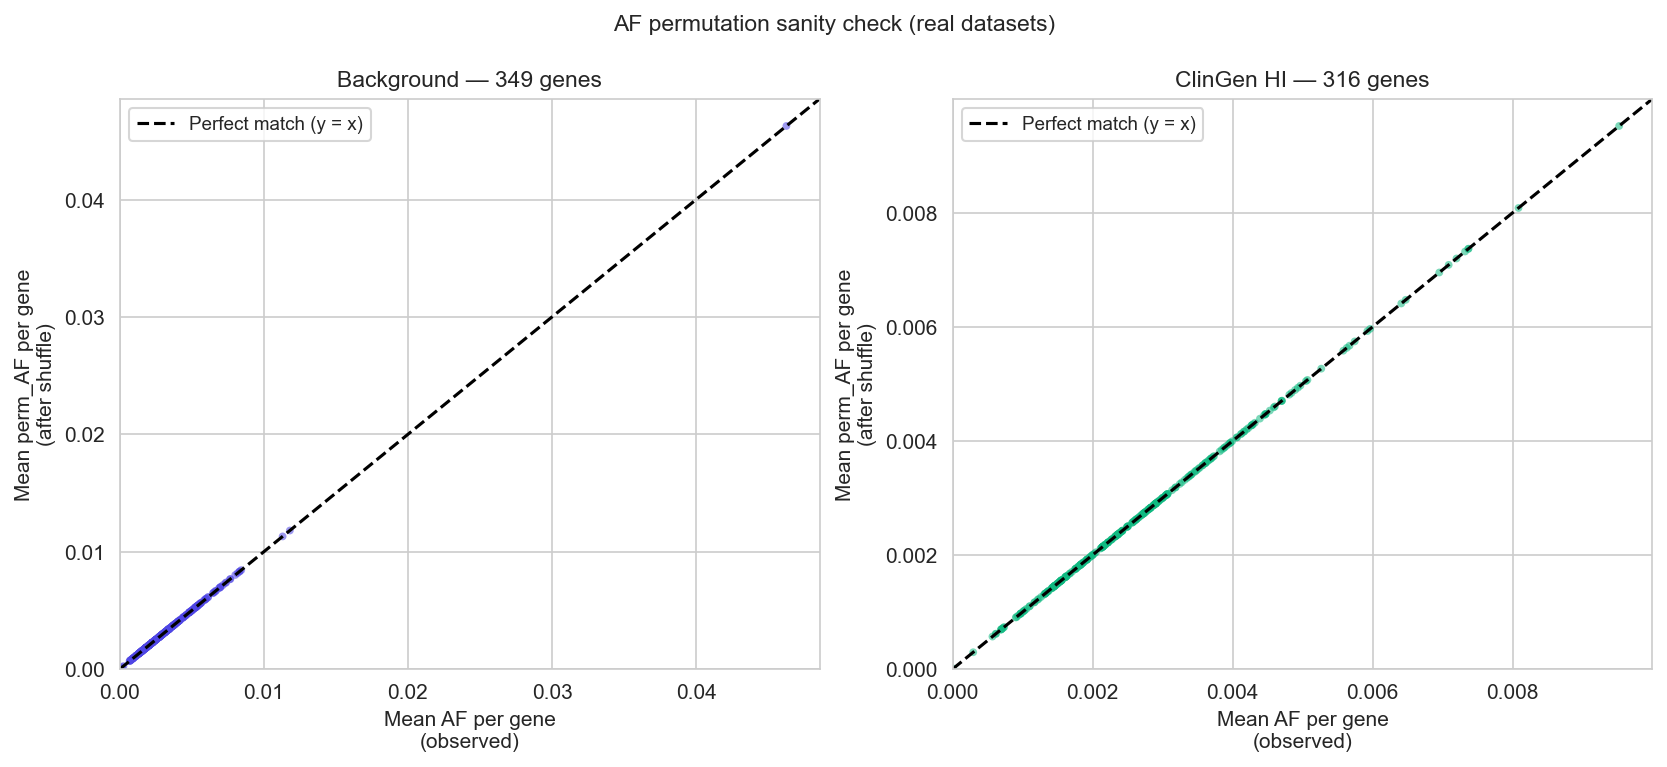

In [7]:
# ── QC Cell 1: AF distribution sanity (real only) ─────────────────────────────
# For each gene, compute the mean AF and mean perm_AF across its variants.
# If the permutation is correct (within-gene shuffle), the two means must be
# identical → every dot sits exactly on the y = x diagonal.
# Easy read: the closer all points are to the line, the better the shuffle.

with autosave('AF_sanity_meanAF_scatter'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
    fig.suptitle(
        'AF permutation sanity check (real datasets)\n',
        fontsize=11,
    )

    for ax, (src_key, src_label) in zip(
        axes,
        [('background', 'Background'), ('clingen', 'ClinGen HI')],
    ):
        df_v = pl.read_parquet(
            VARIANT_PATHS[src_key], columns=['gene_id', 'AF', 'perm_AF']
        )

        # Per-gene mean AF and mean perm_AF
        gene_means = (
            df_v
            .group_by('gene_id')
            .agg([
                pl.col('AF').drop_nans().mean().alias('mean_AF'),
                pl.col('perm_AF').drop_nans().mean().alias('mean_perm_AF'),
            ])
            .drop_nulls()
            .to_pandas()
        )

        color = SOURCE_PALETTE[src_key]
        lim = gene_means[['mean_AF', 'mean_perm_AF']].max().max() * 1.05

        ax.scatter(
            gene_means['mean_AF'], gene_means['mean_perm_AF'],
            s=14, alpha=0.55, color=color, edgecolors='none', rasterized=True,
        )
        ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='Perfect match (y = x)')
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel('Mean AF per gene\n(observed)', fontsize=10)
        ax.set_ylabel('Mean perm_AF per gene\n(after shuffle)', fontsize=10)
        ax.set_title(f'{src_label} — {len(gene_means)} genes', fontsize=11)
        ax.legend(fontsize=9)

        # How far off the diagonal?  Mean absolute difference
        diff = (gene_means['mean_AF'] - gene_means['mean_perm_AF']).abs().mean()
        print(f'{src_label}: {len(gene_means)} genes, '
              f'mean |AF − perm_AF| per gene = {diff:.2e}  (should be ≈ 0)')

Background: n=349, median ratio=1.0448, corr=0.5858
ClinGen HI: n=316, median ratio=0.8553, corr=0.5676
[save_plot] Saved: figuree_Vg_sanity_scatter_and_ratio_14032026_1351.pdf
[save_plot] Saved: figuree_Vg_sanity_scatter_and_ratio_14032026_1351.svg
Vg perm_sanity scatter and ratio done.


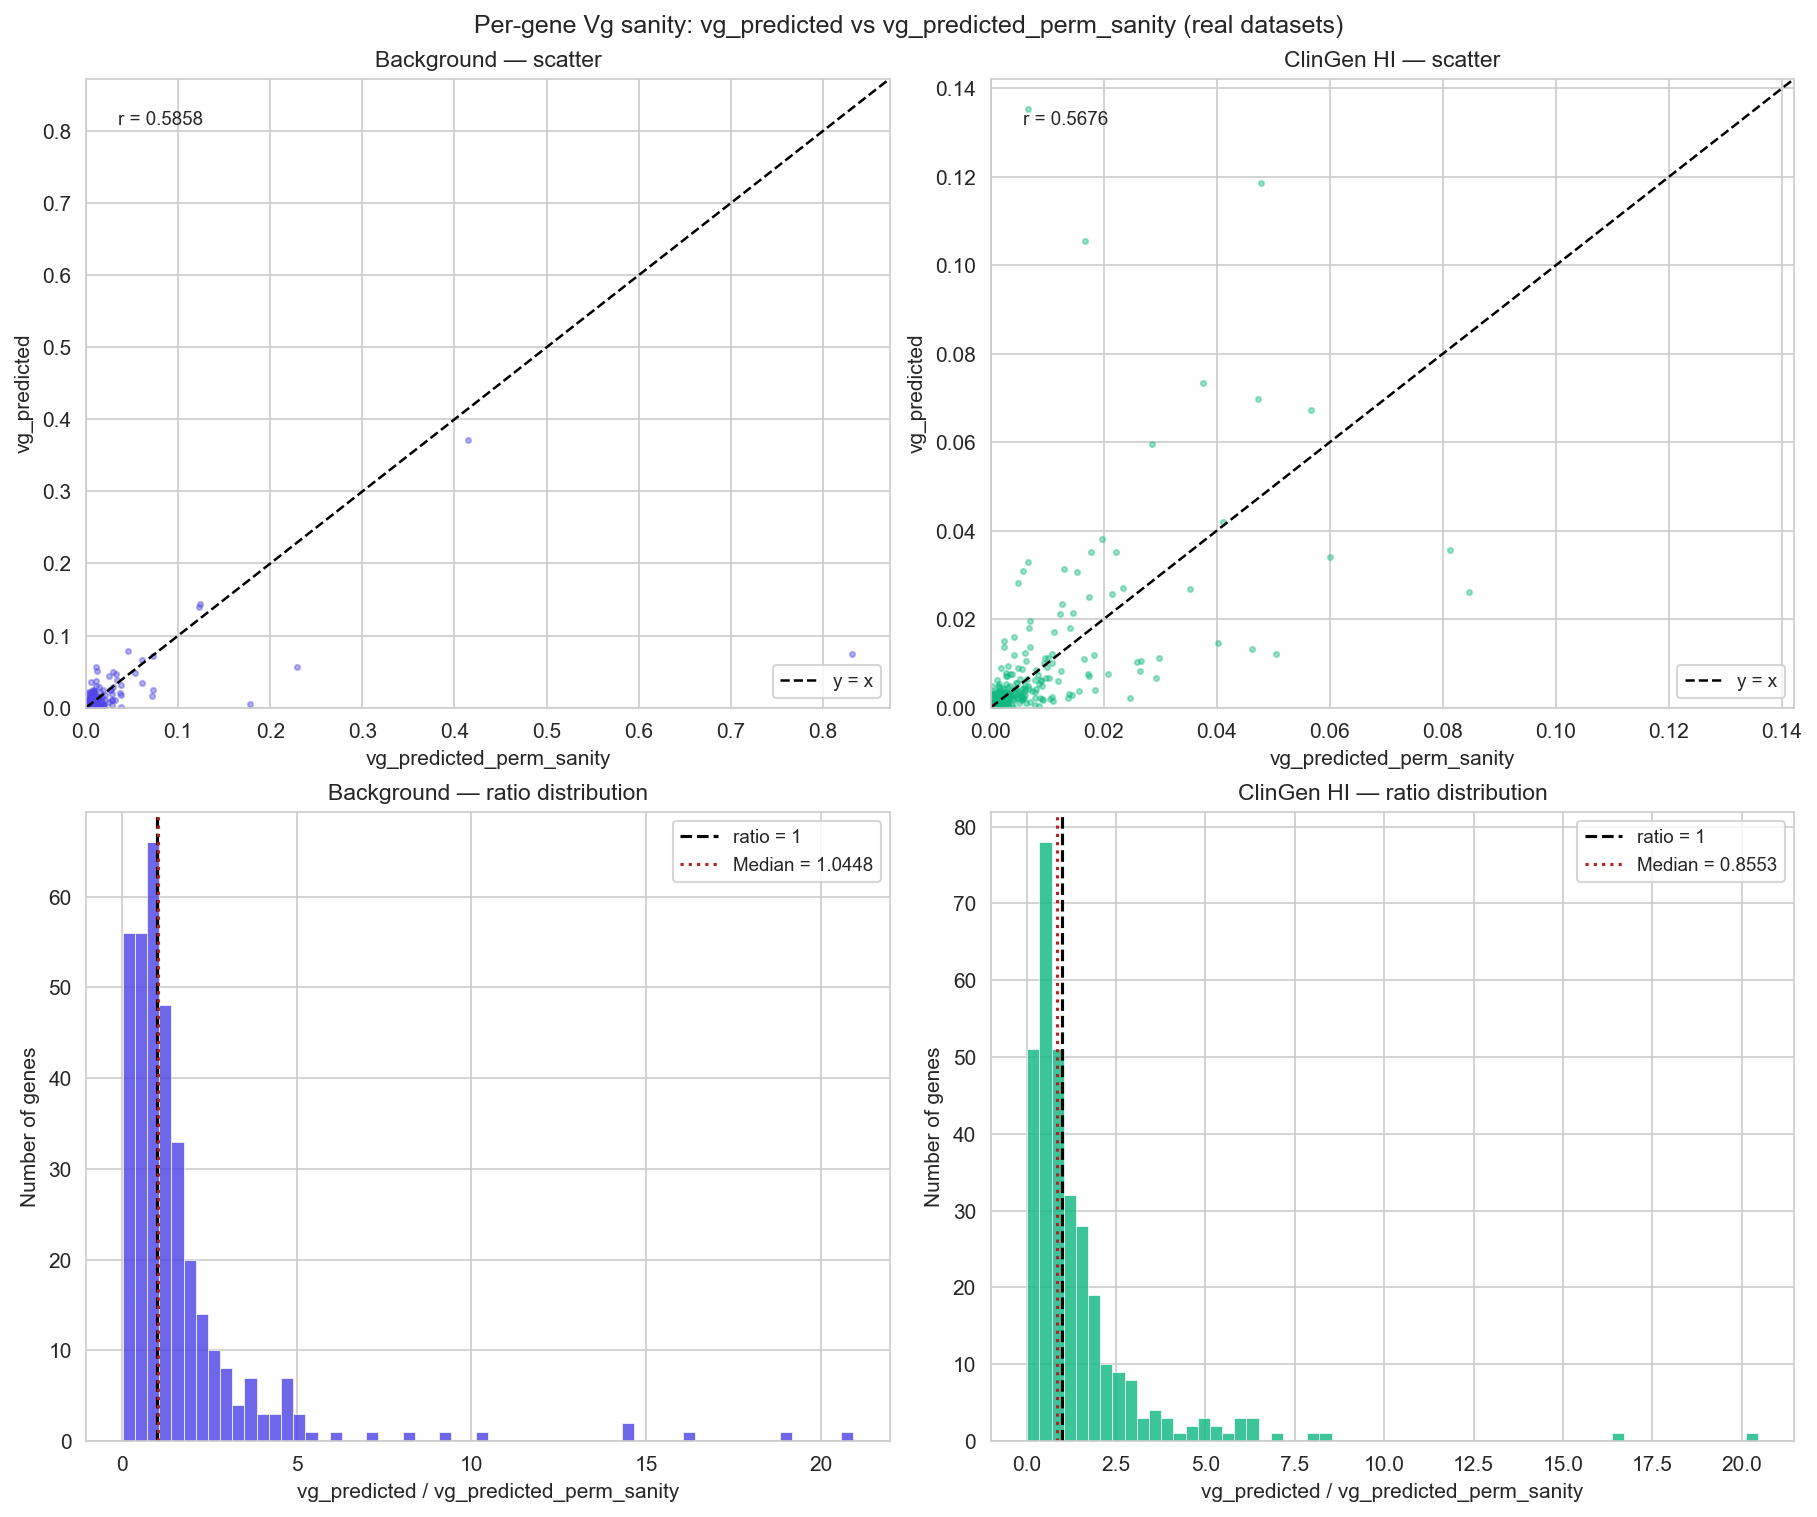

In [8]:
# ── QC Cell 2: Per-gene Vg sanity (real only) ─────────────────────────────────
# Scatter: vg_predicted vs vg_predicted_perm_sanity with y=x diagonal.
# Ratio histogram: vg_predicted / vg_predicted_perm_sanity.
# NOTE: vg_predicted_perm_sanity is an internal QC column only — not a biological null.

with autosave('Vg_sanity_scatter_and_ratio'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    fig.suptitle(
        'Per-gene Vg sanity: vg_predicted vs vg_predicted_perm_sanity (real datasets)',
        fontsize=12,
    )

    for col_idx, (df_src, src_key, src_label) in enumerate([
        (df_bg, 'background', 'Background'),
        (df_hi, 'clingen', 'ClinGen HI'),
    ]):
        color = SOURCE_PALETTE[src_key]
        df_pd = (
            df_src.select(['vg_predicted', 'vg_predicted_perm_sanity'])
            .to_pandas()
            .dropna()
        )

        # ── scatter ──────────────────────────────────────────────────────────
        ax_sc = axes[0, col_idx]
        lim_max = df_pd[['vg_predicted', 'vg_predicted_perm_sanity']].max().max() * 1.05
        ax_sc.scatter(
            df_pd['vg_predicted_perm_sanity'], df_pd['vg_predicted'],
            s=6, alpha=0.4, color=color, rasterized=True,
        )
        ax_sc.plot([0, lim_max], [0, lim_max], 'k--', lw=1.2, label='y = x')
        ax_sc.set_xlim(0, lim_max)
        ax_sc.set_ylim(0, lim_max)
        ax_sc.set_xlabel('vg_predicted_perm_sanity', fontsize=10)
        ax_sc.set_ylabel('vg_predicted', fontsize=10)
        ax_sc.set_title(f'{src_label} — scatter', fontsize=11)
        corr = df_pd.corr()['vg_predicted']['vg_predicted_perm_sanity']
        ax_sc.text(0.04, 0.95, f'r = {corr:.4f}',
                   transform=ax_sc.transAxes, fontsize=9, va='top')
        ax_sc.legend(fontsize=9)

        # ── ratio histogram ───────────────────────────────────────────────────
        ax_ratio = axes[1, col_idx]
        ratio = (
            df_pd['vg_predicted'] / df_pd['vg_predicted_perm_sanity']
        ).replace([np.inf, -np.inf], np.nan).dropna()
        med_r = ratio.median()
        ax_ratio.hist(ratio, bins=60, color=color, alpha=0.82, edgecolor='white', linewidth=0.4)
        ax_ratio.axvline(1.0, color='black', lw=1.5, ls='--', label='ratio = 1')
        ax_ratio.axvline(med_r, color='firebrick', lw=1.5, ls=':', label=f'Median = {med_r:.4f}')
        ax_ratio.set_xlabel('vg_predicted / vg_predicted_perm_sanity', fontsize=10)
        ax_ratio.set_ylabel('Number of genes', fontsize=10)
        ax_ratio.set_title(f'{src_label} — ratio distribution', fontsize=11)
        ax_ratio.legend(fontsize=9)
        print(f'{src_label}: n={len(ratio)}, median ratio={med_r:.4f}, corr={corr:.4f}')

print('Vg perm_sanity scatter and ratio done.')

Background: matched genes=349, median obs/synth=5.0217, IQR=[1.8472, 13.6161]
ClinGen HI: matched genes=316, median obs/synth=4.1539, IQR=[1.4767, 13.1356]
[save_plot] Saved: figuree_Synth_model_check_vg_perm_distributions_14032026_1351.pdf
[save_plot] Saved: figuree_Synth_model_check_vg_perm_distributions_14032026_1351.svg
Synth model check done.


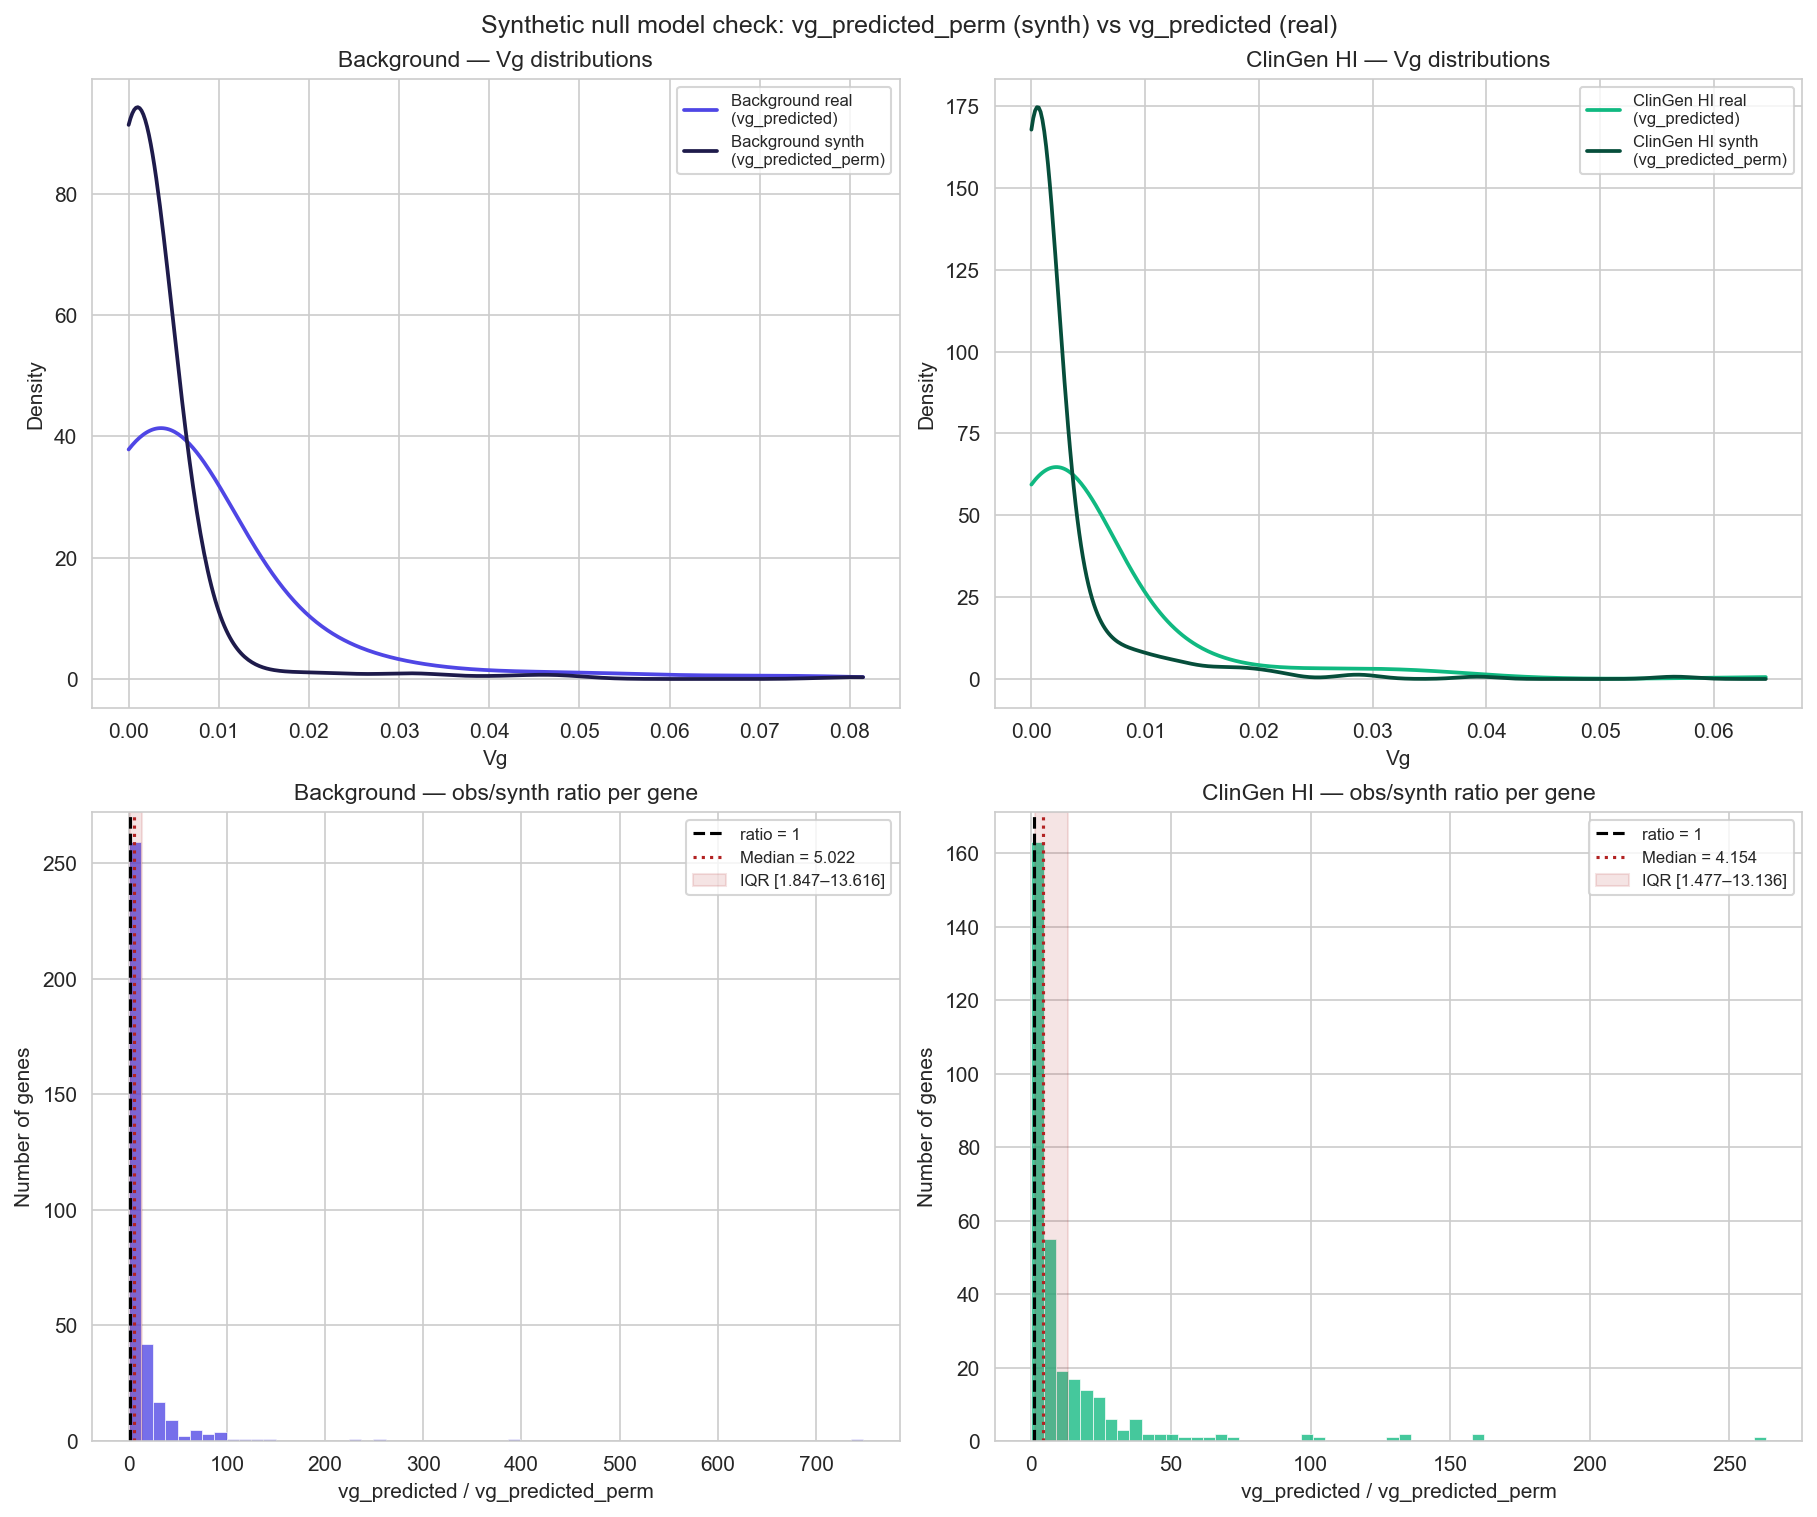

In [9]:

# ── QC Cell 3: Null model check (synthetic datasets) ──────────────────────────
# Top row: density of vg_predicted_perm (synth) vs vg_predicted (real) per group.
# Bottom row: per-gene obs/synth ratio histogram after joining on gene_id.

from scipy.stats import gaussian_kde

with autosave('Synth_model_check_vg_perm_distributions'):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    fig.suptitle(
        'Synthetic null model check: vg_predicted_perm (synth) vs vg_predicted (real)',
        fontsize=12,
    )

    pairs = [
        (df_bg, df_bg_synth, 'background', 'background_null', 'Background'),
        (df_hi, df_hi_synth, 'clingen',    'clingen_null',    'ClinGen HI'),
    ]

    for col_idx, (df_r, df_s, src_real, src_null, label) in enumerate(pairs):
        c_real = SOURCE_PALETTE[src_real]
        c_null = SOURCE_PALETTE[src_null]

        # ── density curves ────────────────────────────────────────────────────
        ax_d = axes[0, col_idx]
        real_vals = df_r['vg_predicted'].drop_nulls().to_numpy()
        perm_vals = df_s['vg_predicted_perm'].drop_nulls().to_numpy()
        xlim = np.nanpercentile(np.concatenate([real_vals, perm_vals]), 99) * 1.1

        for vals, color, lbl in [
            (real_vals, c_real, f'{label} real\n(vg_predicted)'),
            (perm_vals, c_null, f'{label} synth\n(vg_predicted_perm)'),
        ]:
            positive = vals[vals > 0]
            if len(positive) > 1:
                kde = gaussian_kde(positive)
                xs = np.linspace(0, xlim, 400)
                ax_d.plot(xs, kde(xs), color=color, lw=1.8, label=lbl)

        ax_d.set_xlabel('Vg', fontsize=10)
        ax_d.set_ylabel('Density', fontsize=10)
        ax_d.set_title(f'{label} — Vg distributions', fontsize=11)
        ax_d.legend(fontsize=8)

        # ── obs/synth paired ratio per gene ───────────────────────────────────
        ax_r = axes[1, col_idx]
        df_r_pd = (
            df_r.select(['gene_id', 'vg_predicted']).to_pandas()
            .rename(columns={'vg_predicted': 'obs'})
        )
        df_s_pd = (
            df_s.select(['gene_id', 'vg_predicted_perm']).to_pandas()
            .rename(columns={'vg_predicted_perm': 'synth'})
        )
        merged = df_r_pd.merge(df_s_pd, on='gene_id', how='inner')
        merged['ratio'] = (
            merged['obs'] / merged['synth']
        ).replace([np.inf, -np.inf], np.nan)
        merged = merged.dropna(subset=['ratio'])
        med_r = merged['ratio'].median()
        q25, q75 = merged['ratio'].quantile([0.25, 0.75])

        ax_r.hist(merged['ratio'], bins=60, color=c_real, alpha=0.78, edgecolor='white', linewidth=0.4)
        ax_r.axvline(1.0, color='black', lw=1.5, ls='--', label='ratio = 1')
        ax_r.axvline(med_r, color='firebrick', lw=1.5, ls=':', label=f'Median = {med_r:.3f}')
        ax_r.axvspan(q25, q75, alpha=0.12, color='firebrick',
                     label=f'IQR [{q25:.3f}–{q75:.3f}]')
        ax_r.set_xlabel('vg_predicted / vg_predicted_perm', fontsize=10)
        ax_r.set_ylabel('Number of genes', fontsize=10)
        ax_r.set_title(f'{label} — obs/synth ratio per gene', fontsize=11)
        ax_r.legend(fontsize=8)
        print(
            f'{label}: matched genes={len(merged)}, '
            f'median obs/synth={med_r:.4f}, IQR=[{q25:.4f}, {q75:.4f}]'
        )

print('Synth model check done.')


Background
Vg / Vg_perm_sanity: n=349, median=1.0448, IQR=[0.5245, 1.8306] (≥3 genes clipped)
ClinGen HI
Vg / Vg_perm_sanity: n=316, median=0.8553, IQR=[0.5043, 1.6656] (≥2 genes clipped)
Background
Vg_obs / Vg_null: n=349, median=5.0217, IQR=[1.8472, 13.6161] (≥4 genes clipped)
ClinGen HI
Vg_obs / Vg_null: n=316, median=4.1539, IQR=[1.4767, 13.1356] (≥3 genes clipped)
[save_plot] Saved: figuree_Vg_sanity_4panel_summary_14032026_1351.pdf
[save_plot] Saved: figuree_Vg_sanity_4panel_summary_14032026_1351.svg
4-panel summary figure done.


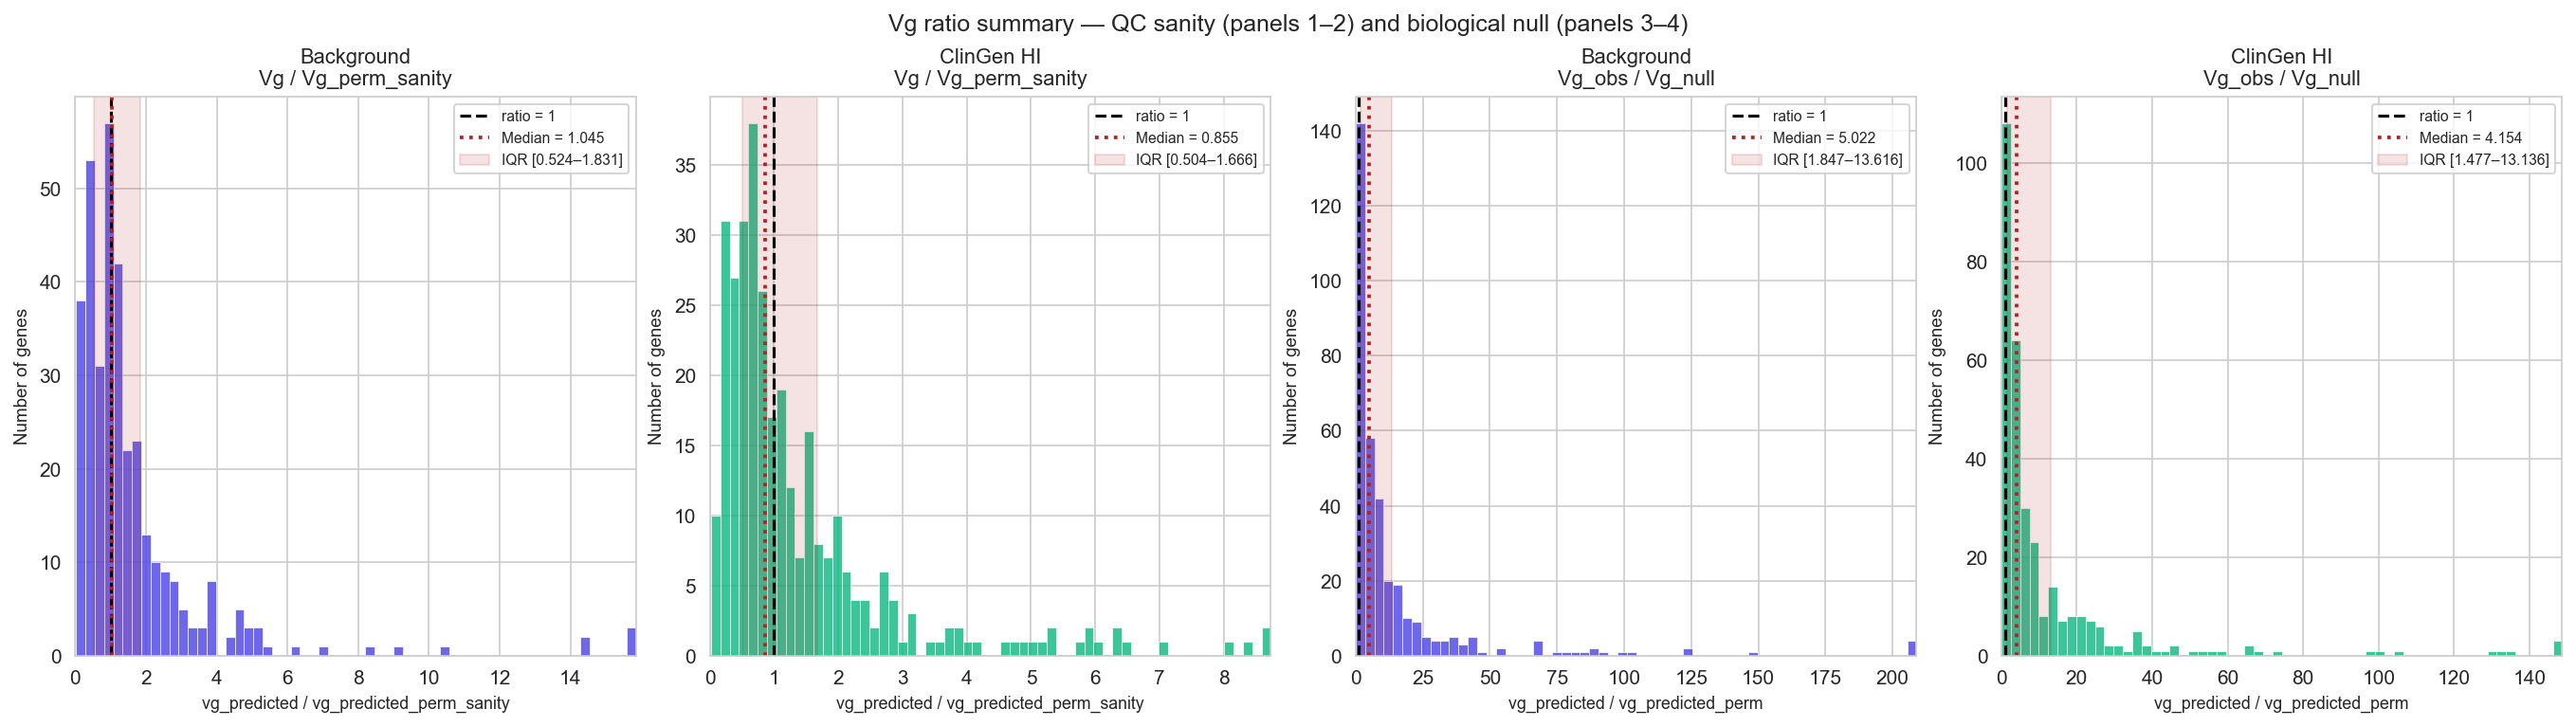

In [10]:
# ── QC Cell 4: Final 4-panel summary figure ───────────────────────────────────
# Panel 1 — Background  real sanity ratio  (vg_predicted / vg_predicted_perm_sanity)
# Panel 2 — ClinGen HI real sanity ratio  (vg_predicted / vg_predicted_perm_sanity)
# Panel 3 — Background  obs/null ratio    (vg_predicted / vg_predicted_perm, gene-joined)
# Panel 4 — ClinGen HI obs/null ratio    (vg_predicted / vg_predicted_perm, gene-joined)
# Each panel shows: histogram + median marker + IQR band + ratio=1 reference.
# X-axis is clipped to the 99th percentile of each panel's data.
#
# NOTE: Panels 1–2 use vg_predicted_perm_sanity for internal QC only.
#       Panels 3–4 use vg_predicted_perm from synthetic null files — the biological null.

with autosave('Vg_sanity_4panel_summary'):
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)
    fig.suptitle(
        'Vg ratio summary — QC sanity (panels 1–2) and biological null (panels 3–4)',
        fontsize=12,
    )

    def _sanity_ratio(df_src):
        df_pd = df_src.select(['vg_predicted', 'vg_predicted_perm_sanity']).to_pandas().dropna()
        return (df_pd['vg_predicted'] / df_pd['vg_predicted_perm_sanity']).replace([np.inf, -np.inf], np.nan).dropna()

    def _null_ratio(df_r, df_s):
        merged = (
            df_r.select(['gene_id', 'vg_predicted']).to_pandas()
            .merge(df_s.select(['gene_id', 'vg_predicted_perm']).to_pandas(), on='gene_id', how='inner')
        )
        return (merged['vg_predicted'] / merged['vg_predicted_perm']).replace([np.inf, -np.inf], np.nan).dropna()

    panel_specs = [
        ('Background\nVg / Vg_perm_sanity',  'background', 'vg_predicted / vg_predicted_perm_sanity', _sanity_ratio(df_bg)),
        ('ClinGen HI\nVg / Vg_perm_sanity',  'clingen',    'vg_predicted / vg_predicted_perm_sanity', _sanity_ratio(df_hi)),
        ('Background\nVg_obs / Vg_null',      'background', 'vg_predicted / vg_predicted_perm',        _null_ratio(df_bg, df_bg_synth)),
        ('ClinGen HI\nVg_obs / Vg_null',      'clingen',    'vg_predicted / vg_predicted_perm',        _null_ratio(df_hi, df_hi_synth)),
    ]

    for ax, (title, color_key, x_label, ratio) in zip(axes, panel_specs):
        color = SOURCE_PALETTE[color_key]
        med = ratio.median()
        q25, q75 = ratio.quantile([0.25, 0.75])
        x_clip = float(ratio.quantile(0.99)) * 1.1   # show 99 % of data

        # Clip histogram to the same range so bins aren't wasted on the tail
        ratio_clipped = ratio.clip(upper=x_clip)

        ax.hist(ratio_clipped, bins=60, color=color, alpha=0.82, edgecolor='white', linewidth=0.4)
        ax.axvline(1.0,  color='black',     lw=1.5, ls='--', label='ratio = 1')
        ax.axvline(med,  color='firebrick', lw=1.8, ls=':',  label=f'Median = {med:.3f}')
        ax.axvspan(q25, min(q75, x_clip), alpha=0.13, color='firebrick',
                   label=f'IQR [{q25:.3f}–{q75:.3f}]')
        ax.set_xlim(0, x_clip)
        ax.set_title(title, fontsize=10.5)
        ax.set_xlabel(x_label, fontsize=8.5)
        ax.set_ylabel('Number of genes', fontsize=9)
        ax.legend(fontsize=7.5)
        n_clipped = int((ratio > x_clip).sum())
        clip_note = f' (≥{n_clipped} genes clipped)' if n_clipped else ''
        print(f'{title.strip()}: n={len(ratio)}, median={med:.4f}, IQR=[{q25:.4f}, {q75:.4f}]{clip_note}')

print('4-panel summary figure done.')

# 1. VG distribution between datasets

Background_Gnomad: median CI = [1.061e-03, 1.082e-02]  (CI_mean=4.485e-03)
ClinGen_HI_Gnomad: median CI = [9.223e-04, 7.421e-03]  (CI_mean=3.199e-03)
[save_plot] Saved: figuree_AF_Cutoff_VgPredicted_Boxplot_WithSignificance_14032026_1351.pdf
[save_plot] Saved: figuree_AF_Cutoff_VgPredicted_Boxplot_WithSignificance_14032026_1351.svg


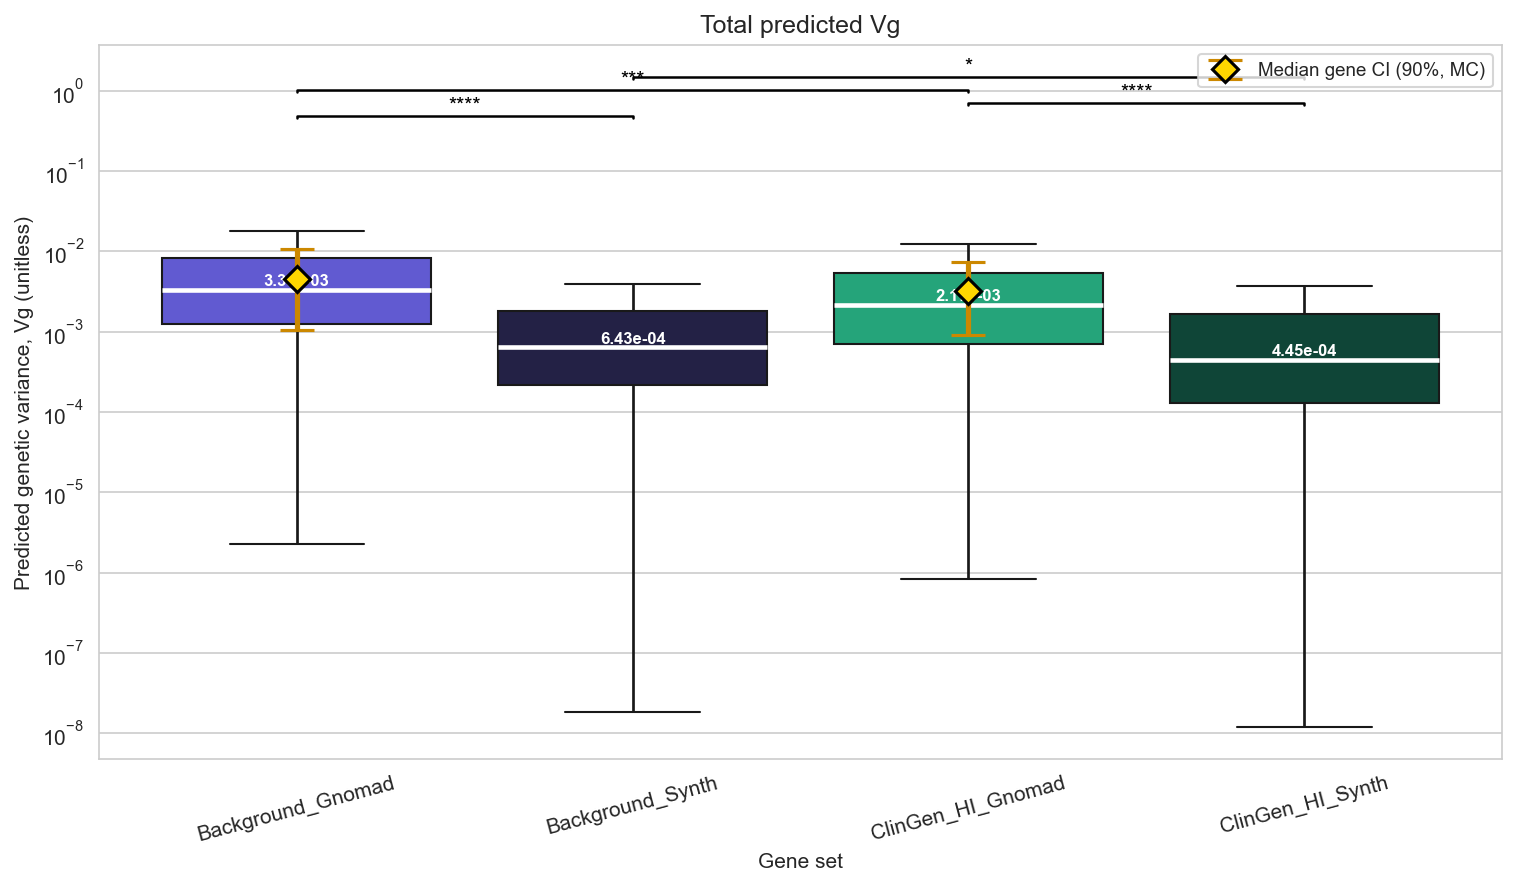

In [11]:
with autosave('AF_Cutoff_VgPredicted_Boxplot_WithSignificance'):
    fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
    sns.boxplot(
        data=plot_df,
        x='source_label',
        y='vg_total_for_plot',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        dodge=False,
        legend=False,
        showfliers=False,
        medianprops={'color': 'white', 'linewidth': 2.2},
        whiskerprops={'linewidth': 1.3},
        ax=ax,
    )
    ax.set_yscale('log')
    annotate_medians(ax, plot_df, 'source_label', 'vg_total_for_plot', source_label_order, text_color='white')
    add_sig_brackets(
        ax,
        plot_df,
        x_col='source_label',
        y_col='vg_total_for_plot',
        order=source_label_order,
        pairs=[
            ('Background_Gnomad', 'Background_Synth'),
            ('ClinGen_HI_Gnomad', 'ClinGen_HI_Synth'),
            ('Background_Gnomad', 'ClinGen_HI_Gnomad'),
            ('Background_Synth', 'ClinGen_HI_Synth'),
        ],
    )

    # ── Overlay Monte Carlo CIs (real datasets only) ──────────────────────────
    # CI columns = per-gene AF-resampling uncertainty (90% interval: p05–p95).
    # We show the median CI_p05 and CI_p95 across all genes in each real group,
    # i.e., the typical Vg estimation uncertainty for a single gene.
    # CIs are NOT shown for synth groups: their vg_predicted_CI columns describe
    # CI around vg_predicted (observed AF), not around vg_predicted_perm.
    CI_COLOR  = '#FFD700'   # gold — high contrast on both blue/teal box fills
    CI_ECOLOR = '#CC8800'   # darker amber for error bar lines

    ci_real_sources = [
        (df_bg, 'Background_Gnomad', 'background'),
        (df_hi, 'ClinGen_HI_Gnomad', 'clingen'),
    ]
    ci_plotted = False
    for df_src, src_label, src_key in ci_real_sources:
        ci_cols_needed = ['vg_predicted_CI_p05', 'vg_predicted_CI_p95', 'vg_predicted_CI_mean']
        if not all(c in df_src.columns for c in ci_cols_needed):
            print(f'  [skip CI] {src_label}: CI columns not found')
            continue
        ci_pd = df_src.select(ci_cols_needed).to_pandas().dropna()
        med_p05  = ci_pd['vg_predicted_CI_p05'].median()
        med_p95  = ci_pd['vg_predicted_CI_p95'].median()
        med_mean = ci_pd['vg_predicted_CI_mean'].median()
        x_pos = source_label_order.index(src_label)
        label_ci = 'Median gene CI (90%, MC)' if not ci_plotted else '_nolegend_'
        ax.errorbar(
            x_pos, med_mean,
            yerr=[[med_mean - med_p05], [med_p95 - med_mean]],
            fmt='D',
            color=CI_COLOR,
            ecolor=CI_ECOLOR,
            elinewidth=2.5,
            capsize=8,
            capthick=2.5,
            markersize=9,
            markeredgecolor='black',
            markeredgewidth=1.5,
            zorder=15,
            label=label_ci,
        )
        ci_plotted = True
        print(
            f'{src_label}: median CI = [{med_p05:.3e}, {med_p95:.3e}]  '
            f'(CI_mean={med_mean:.3e})'
        )

    ax.set_xlabel('Gene set', fontsize=10)
    ax.set_ylabel('Predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Total predicted Vg')
    ax.tick_params(axis='x', rotation=15)
    if ci_plotted:
        ax.legend(loc='upper right', fontsize=9, frameon=True)


# 1. AF cutoffs - rare vs common predicted VG

Rare (AF < 0.05) / Background_Gnomad: median CI = [2.835e-04, 1.860e-03]  (CI_mean=8.056e-04)
Rare (AF < 0.05) / ClinGen_HI_Gnomad: median CI = [2.422e-04, 1.278e-03]  (CI_mean=6.125e-04)
Common (AF ≥ 0.05) / Background_Gnomad: median CI = [4.325e-04, 9.561e-03]  (CI_mean=3.694e-03)
Common (AF ≥ 0.05) / ClinGen_HI_Gnomad: median CI = [3.496e-04, 6.680e-03]  (CI_mean=2.560e-03)
[save_plot] Saved: figuree_AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette_14032026_1351.pdf
[save_plot] Saved: figuree_AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette_14032026_1351.svg


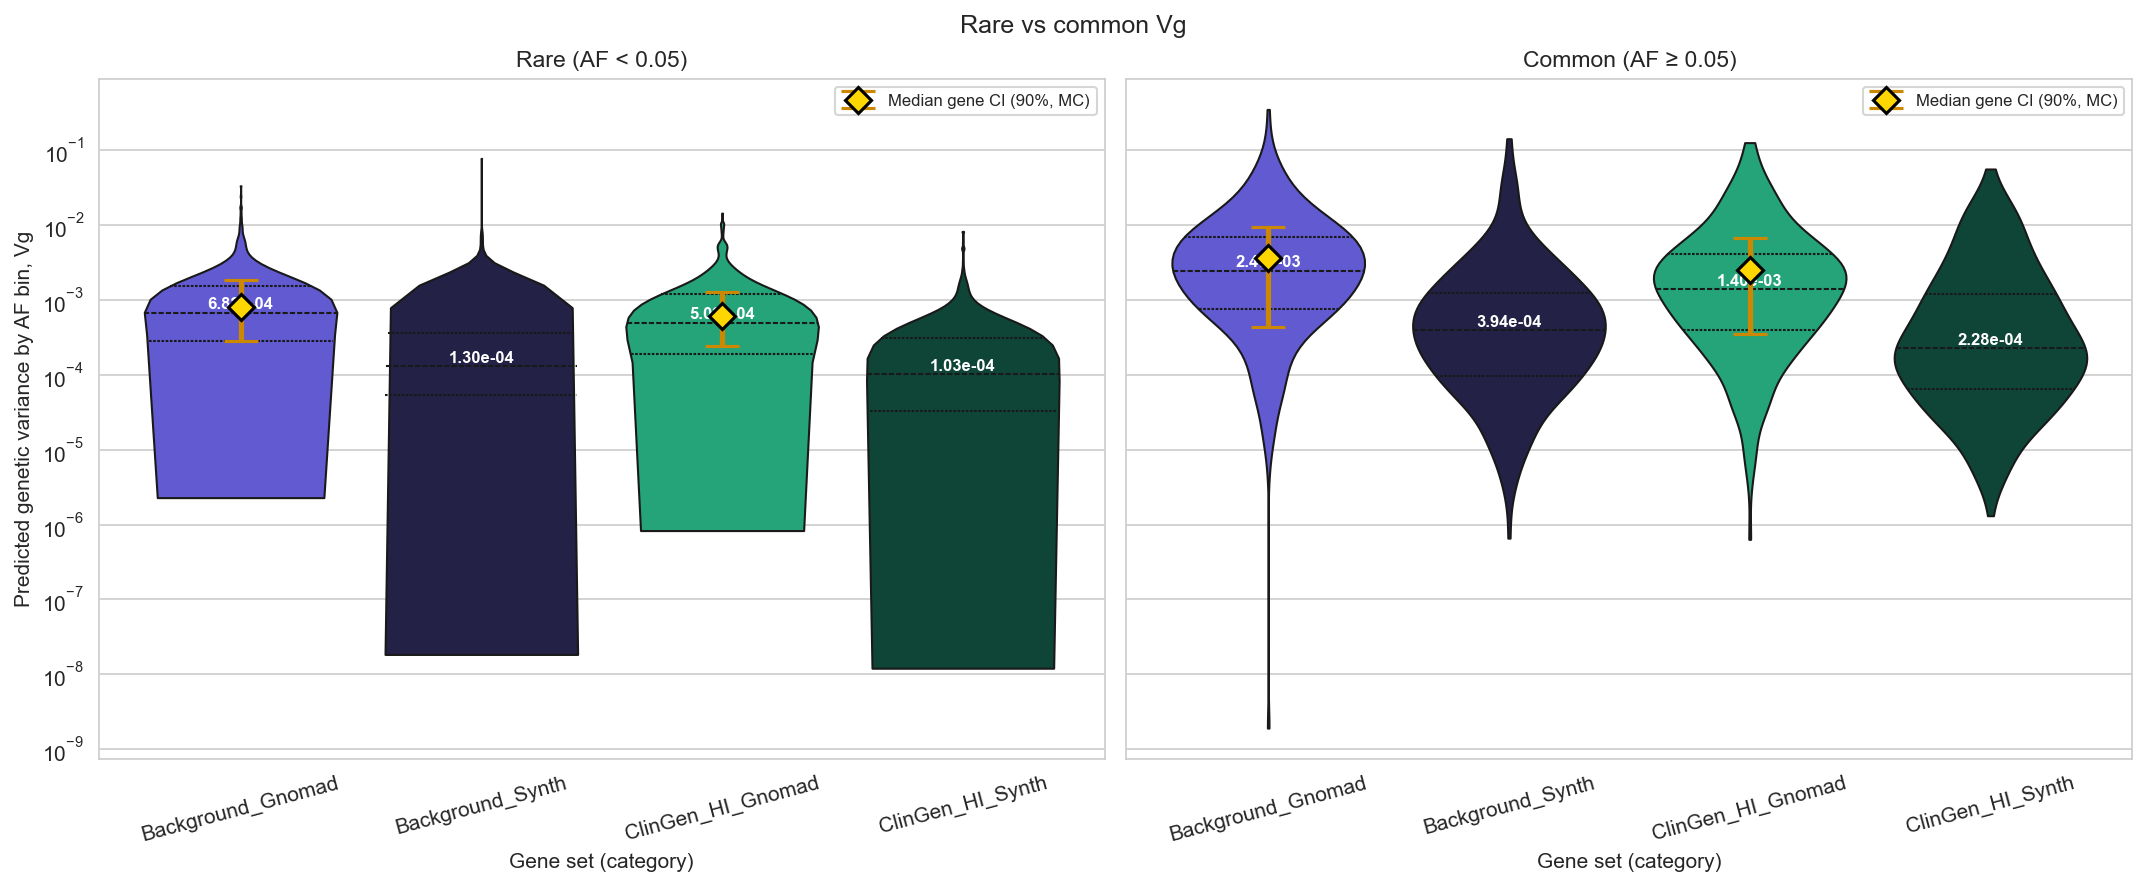

In [12]:
vg_long = plot_df.melt(
    id_vars=['source', 'source_label'],
    value_vars=['vg_rare_for_plot', 'vg_common_for_plot'],
    var_name='af_group',
    value_name='vg_component',
)
vg_long['af_group'] = vg_long['af_group'].map({
    'vg_rare_for_plot': 'Rare (AF < 0.05)',
    'vg_common_for_plot': 'Common (AF ≥ 0.05)',
})
vg_long = vg_long[vg_long['vg_component'] > 0].copy()
af_order = ['Rare (AF < 0.05)', 'Common (AF ≥ 0.05)']

# Map each AF bin to its CI column prefix (per AGENTS.md: CIs on real datasets only)
AF_CI_PREFIX = {
    'Rare (AF < 0.05)':    'vg_rare',
    'Common (AF ≥ 0.05)': 'vg_common',
}
CI_COLOR  = '#FFD700'
CI_ECOLOR = '#CC8800'
CI_REAL_SOURCES = [
    (df_bg, 'Background_Gnomad'),
    (df_hi, 'ClinGen_HI_Gnomad'),
]

with autosave('AF_Cutoff_Violin_Rare_vs_Common_BySourcePalette'):
    fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.8), sharey=True, constrained_layout=True)

    for ax, af_class in zip(axes, af_order):
        sub = vg_long[vg_long['af_group'] == af_class]
        sns.violinplot(
            data=sub,
            x='source_label',
            y='vg_component',
            hue='source_label',
            order=source_label_order,
            hue_order=source_label_order,
            palette=palette_by_label,
            dodge=False,
            legend=False,
            inner='quart',
            cut=0,
            bw_adjust=1.0,
            linewidth=1.0,
            ax=ax,
        )
        ax.set_yscale('log')
        annotate_medians(ax, sub, 'source_label', 'vg_component', source_label_order, text_color='white')
        ax.set_title(af_class, fontsize=11)
        ax.set_xlabel('Gene set (category)', fontsize=10)
        ax.tick_params(axis='x', rotation=15)

        # ── Overlay Monte Carlo CIs (real datasets only) ──────────────────────
        ci_prefix = AF_CI_PREFIX[af_class]
        ci_cols_needed = [f'{ci_prefix}_CI_p05', f'{ci_prefix}_CI_p95', f'{ci_prefix}_CI_mean']
        ci_plotted_panel = False
        for df_src, src_label in CI_REAL_SOURCES:
            if not all(c in df_src.columns for c in ci_cols_needed):
                print(f'  [skip CI] {af_class} / {src_label}: CI columns not found')
                continue
            ci_pd = df_src.select(ci_cols_needed).to_pandas().dropna()
            med_p05  = ci_pd[f'{ci_prefix}_CI_p05'].median()
            med_p95  = ci_pd[f'{ci_prefix}_CI_p95'].median()
            med_mean = ci_pd[f'{ci_prefix}_CI_mean'].median()
            x_pos = source_label_order.index(src_label)
            label_ci = 'Median gene CI (90%, MC)' if not ci_plotted_panel else '_nolegend_'
            ax.errorbar(
                x_pos, med_mean,
                yerr=[[med_mean - med_p05], [med_p95 - med_mean]],
                fmt='D',
                color=CI_COLOR,
                ecolor=CI_ECOLOR,
                elinewidth=2.5,
                capsize=8,
                capthick=2.5,
                markersize=9,
                markeredgecolor='black',
                markeredgewidth=1.5,
                zorder=15,
                label=label_ci,
            )
            ci_plotted_panel = True
            print(
                f'{af_class} / {src_label}: median CI = [{med_p05:.3e}, {med_p95:.3e}]'
                f'  (CI_mean={med_mean:.3e})'
            )
        if ci_plotted_panel:
            ax.legend(loc='upper right', fontsize=8, frameon=True)

    axes[0].set_ylabel('Predicted genetic variance by AF bin, Vg', fontsize=10)
    axes[1].set_ylabel('')
    fig.suptitle('Rare vs common Vg', fontsize=12)


# 1c. Stacked Vg Contribution - Absolute Mean Values

[save_plot] Saved: figuree_AF_Cutoff_Stacked_RareCommon_MeanVg_14032026_1351.pdf
[save_plot] Saved: figuree_AF_Cutoff_Stacked_RareCommon_MeanVg_14032026_1351.svg


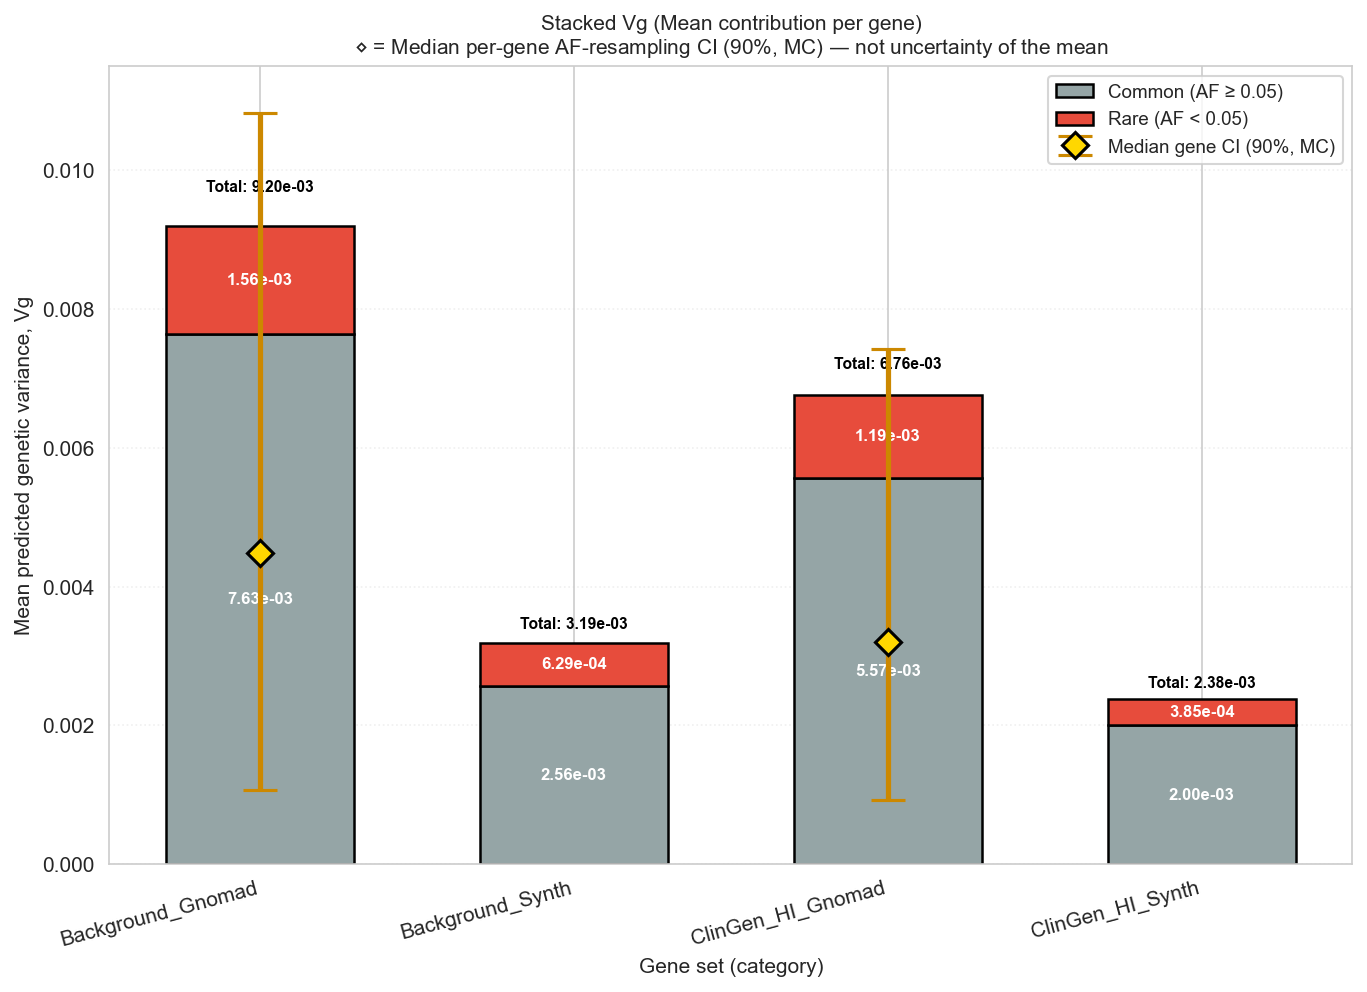

In [13]:
# Plot 3: Stacked Vg Contribution - Mean values for rare and common
stacked_df = plot_df.groupby('source_label', as_index=False).agg({
    'vg_common_for_plot': 'mean',
    'vg_rare_for_plot': 'mean',
    'vg_total_for_plot': 'mean',
})

CI_COLOR  = '#FFD700'
CI_ECOLOR = '#CC8800'

# Collect median per-gene CI for total Vg (real datasets only, per AGENTS.md)
# These CIs represent AF-resampling uncertainty for a typical single gene,
# NOT the uncertainty of the group mean shown by the bar.
ci_for_bars = {}  # src_label -> (med_p05, med_mean, med_p95)
for df_src, src_label in [(df_bg, 'Background_Gnomad'), (df_hi, 'ClinGen_HI_Gnomad')]:
    ci_cols = ['vg_predicted_CI_p05', 'vg_predicted_CI_p95', 'vg_predicted_CI_mean']
    if all(c in df_src.columns for c in ci_cols):
        ci_pd = df_src.select(ci_cols).to_pandas().dropna()
        ci_for_bars[src_label] = (
            ci_pd['vg_predicted_CI_p05'].median(),
            ci_pd['vg_predicted_CI_mean'].median(),
            ci_pd['vg_predicted_CI_p95'].median(),
        )

with autosave('AF_Cutoff_Stacked_RareCommon_MeanVg'):
    fig, ax = plt.subplots(figsize=(9.0, 6.5), constrained_layout=True)

    x_positions = np.arange(len(source_label_order))
    width = 0.6

    # Stacked bars: common on bottom, rare on top
    bars_common = ax.bar(
        x_positions,
        stacked_df.set_index('source_label').loc[source_label_order, 'vg_common_for_plot'],
        width,
        label='Common (AF ≥ 0.05)',
        color='#95a5a6',
        edgecolor='black',
        linewidth=1.2,
    )

    bars_rare = ax.bar(
        x_positions,
        stacked_df.set_index('source_label').loc[source_label_order, 'vg_rare_for_plot'],
        width,
        bottom=stacked_df.set_index('source_label').loc[source_label_order, 'vg_common_for_plot'],
        label='Rare (AF < 0.05)',
        color='#e74c3c',
        edgecolor='black',
        linewidth=1.2,
    )

    # Add value labels on each segment
    ci_legend_added = False
    for i, source in enumerate(source_label_order):
        row = stacked_df[stacked_df['source_label'] == source].iloc[0]
        common_val = row['vg_common_for_plot']
        rare_val   = row['vg_rare_for_plot']
        total_val  = row['vg_total_for_plot']

        ax.text(i, common_val / 2, f'{common_val:.2e}',
                ha='center', va='center', fontsize=8, color='white', weight='bold')
        ax.text(i, common_val + rare_val / 2, f'{rare_val:.2e}',
                ha='center', va='center', fontsize=8, color='white', weight='bold')
        ax.text(i, total_val + total_val * 0.05, f'Total: {total_val:.2e}',
                ha='center', va='bottom', fontsize=7.5, color='black', weight='bold')

        # ── Overlay per-gene CI (real groups only) ───────────────────────────
        if source in ci_for_bars:
            med_p05, med_mean, med_p95 = ci_for_bars[source]
            label_ci = 'Median gene CI (90%, MC)' if not ci_legend_added else '_nolegend_'
            ax.errorbar(
                i, med_mean,
                yerr=[[med_mean - med_p05], [med_p95 - med_mean]],
                fmt='D',
                color=CI_COLOR,
                ecolor=CI_ECOLOR,
                elinewidth=2.5,
                capsize=8,
                capthick=2.5,
                markersize=9,
                markeredgecolor='black',
                markeredgewidth=1.5,
                zorder=15,
                label=label_ci,
            )
            ci_legend_added = True

    ax.set_xticks(x_positions)
    ax.set_xticklabels(source_label_order, rotation=15, ha='right')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Mean predicted genetic variance, Vg', fontsize=10)
    ax.set_title(
        'Stacked Vg (Mean contribution per gene)\n'
        r'$\diamond$ = Median per-gene AF-resampling CI (90%, MC) — not uncertainty of the mean',
        fontsize=10,
    )
    ax.legend(loc='upper right', frameon=True, fontsize=9)
    ax.set_ylim(0, stacked_df['vg_total_for_plot'].max() * 1.25)
    ax.grid(axis='y', alpha=0.3, linestyle=':')


# 1b. The "Share" of Variance - Proportion from Common Variants

Calculate prop_common = vg_common / vg_predicted for each gene.

[save_plot] Saved: figuree_AF_Cutoff_CommonVariantShare_Violin_14032026_1351.pdf
[save_plot] Saved: figuree_AF_Cutoff_CommonVariantShare_Violin_14032026_1351.svg
Plot: Common variant share complete.


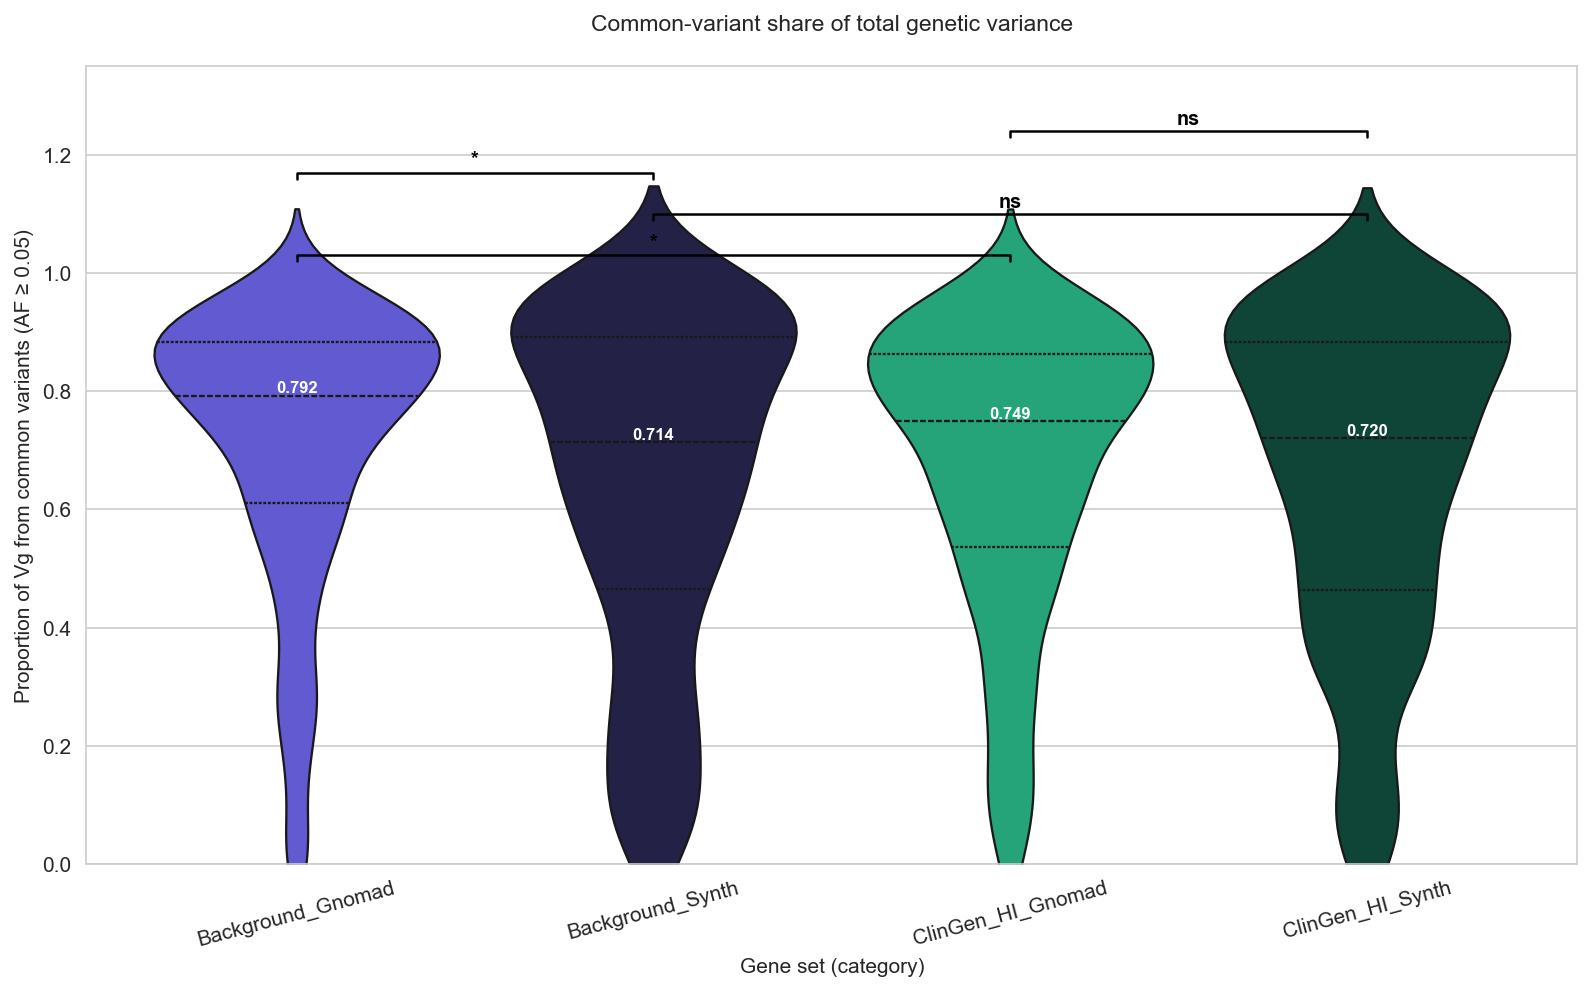

In [14]:
# Calculate vg_common_fraction
if 'vg_common_fraction' not in plot_df.columns:
    plot_df['vg_common_fraction'] = np.where(
        plot_df['vg_total_for_plot'] > 0,
        plot_df['vg_common_for_plot'] / plot_df['vg_total_for_plot'],
        np.nan
    )

share_df = plot_df[plot_df['vg_common_fraction'].notna()].copy()

with autosave('AF_Cutoff_CommonVariantShare_Violin'):
    fig, ax = plt.subplots(figsize=(10.5, 6.5), constrained_layout=True)
    
    sns.violinplot(
        data=share_df,
        x='source_label',
        y='vg_common_fraction',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        dodge=False,
        legend=False,
        inner='quart',
        cut=2,
        bw_adjust=0.85,
        linewidth=1.1,
        ax=ax,
    )
    
    # Add median annotations
    annotate_medians(ax, share_df, 'source_label', 'vg_common_fraction', 
                    source_label_order, fmt='{:.3f}', text_color='white', y_offset_factor=1.0)
    
    # Manual significance brackets for better control on linear scale
    y_data_max = share_df['vg_common_fraction'].max()
    bracket_start = 1.03
    bracket_step = 0.07
    
    pairs_to_test = [
        ('Background_Gnomad', 'ClinGen_HI_Gnomad', 0),
        ('Background_Synth', 'ClinGen_HI_Synth', 1),
        ('Background_Gnomad', 'Background_Synth', 2),
        ('ClinGen_HI_Gnomad', 'ClinGen_HI_Synth', 3),
    ]
    
    for group_a, group_b, level in pairs_to_test:
        a = share_df.loc[share_df['source_label'] == group_a, 'vg_common_fraction'].dropna()
        b = share_df.loc[share_df['source_label'] == group_b, 'vg_common_fraction'].dropna()
        if len(a) < 3 or len(b) < 3:
            continue
        _, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')
        
        x1 = source_label_order.index(group_a)
        x2 = source_label_order.index(group_b)
        y = bracket_start + level * bracket_step
        y_low = y - 0.01
        
        ax.plot([x1, x1, x2, x2], [y_low, y, y, y_low], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y + 0.005, p_to_stars(p_val),
                ha='center', va='bottom', fontsize=9.5, color='black', weight='bold')
    
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Proportion of Vg from common variants (AF ≥ 0.05)', fontsize=10)
    ax.set_title('Common-variant share of total genetic variance\n', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(0, 1.35)

print('Plot: Common variant share complete.')

Common variants (gray) dominate the absolute contribution to mean Vg
Background_Gnomad: 7.29e-03 (common) vs 1.47e-03 (rare) → ~83% common
ClinGen_HI_Gnomad: 5.42e-03 (common) vs 1.15e-03 (rare) → ~82% common


"Common variants contribute substantially to total genetic variance in absolute terms. However, when we zoom in on the PROPORTION (violin plot), we see that ClinGen haploinsufficient genes have a significantly smaller share from common variants - evolution has depleted common regulatory variation in these essential genes through purifying selection."

Here we confirm that ClinGen Haploinsufficient genes are depleted of common regulatory variation. Their total genetic variance is disproportionately driven by rare and ultra-rare variants compared to background genes.

# 2. Regional Vg summary

[save_plot] Saved: figuree_AF_Cutoff_Regional_Simplified_Boxplot_14032026_1351.pdf
[save_plot] Saved: figuree_AF_Cutoff_Regional_Simplified_Boxplot_14032026_1351.svg


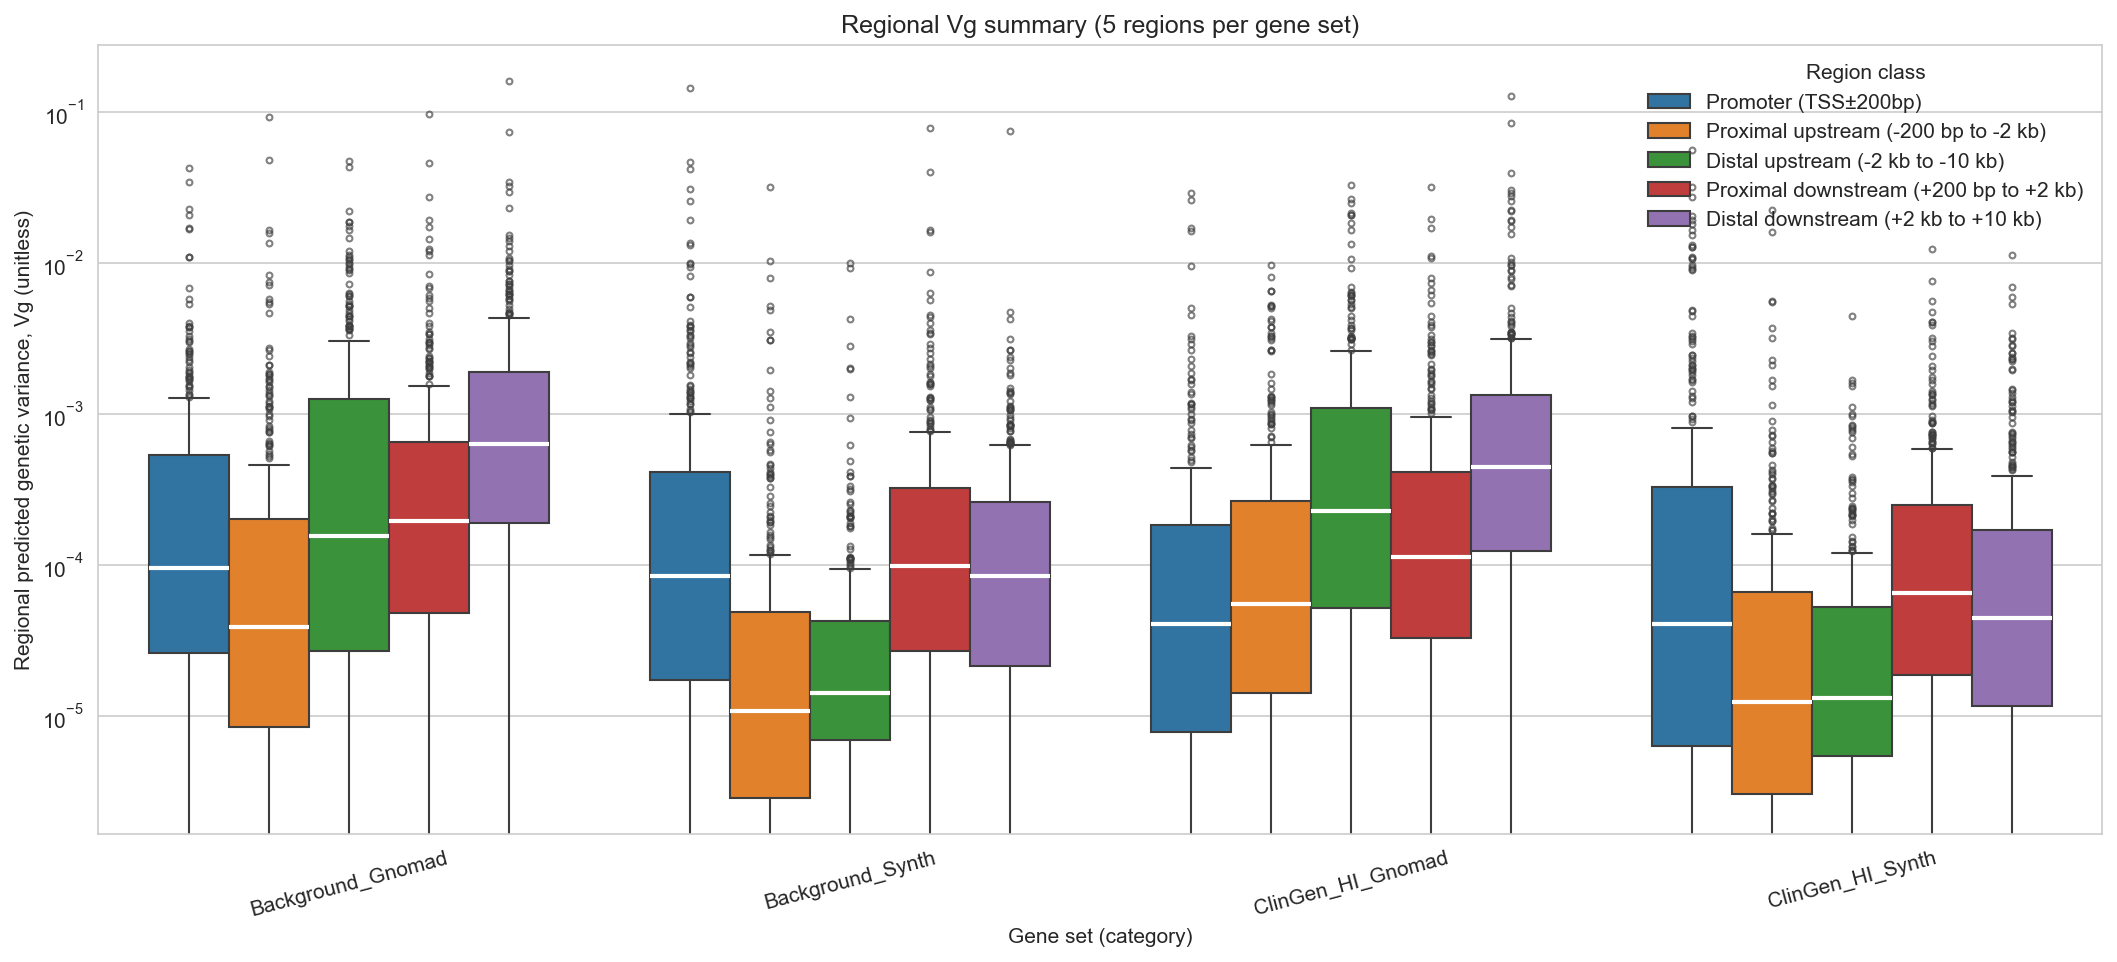

In [15]:
# 3) Regional Vg summary with 5 region boxes per gene set
region_5_long = plot_df.melt(
    id_vars=['source_label'],
    value_vars=[
        'vg_region_promoter_core',
        'vg_region_proximal_upstream',
        'vg_region_distal_upstream',
        'vg_region_down_proximal',
        'vg_region_down_distal',
    ],
    var_name='region_group',
    value_name='region_vg',
)
region_5_labels = {
    'vg_region_promoter_core': 'Promoter (TSS±200bp)',
    'vg_region_proximal_upstream': 'Proximal upstream (-200 bp to -2 kb)',
    'vg_region_distal_upstream': 'Distal upstream (-2 kb to -10 kb)',
    'vg_region_down_proximal': 'Proximal downstream (+200 bp to +2 kb)',
    'vg_region_down_distal': 'Distal downstream (+2 kb to +10 kb)',
}
region_5_order = [
    'Promoter (TSS±200bp)',
    'Proximal upstream (-200 bp to -2 kb)',
    'Distal upstream (-2 kb to -10 kb)',
    'Proximal downstream (+200 bp to +2 kb)',
    'Distal downstream (+2 kb to +10 kb)',
]
region_5_long['region_group'] = region_5_long['region_group'].map(region_5_labels)

with autosave('AF_Cutoff_Regional_Simplified_Boxplot'):
    fig, ax = plt.subplots(figsize=(14.0, 6.3), constrained_layout=True)
    sns.boxplot(
        data=region_5_long,
        x='source_label',
        y='region_vg',
        hue='region_group',
        order=source_label_order,
        hue_order=region_5_order,
        showfliers=True,
        flierprops={'marker': 'o', 'markersize': 2.8, 'alpha': 0.65},
        medianprops={'color': 'white', 'linewidth': 2.0},
        ax=ax,
    )
    ax.set_yscale('log')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Regional predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Regional Vg summary (5 regions per gene set)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Region class', frameon=False)

# 3b. Regional Vg summary collapsed to Promoter / Upstream / Downstream

Background_Gnomad / Promoter (TSS±200bp): median CI = [1.976e-05, 3.102e-03]  (mean=7.782e-04)
Background_Gnomad / Upstream (-200 bp to -10 kb): median CI = [4.887e-05, 2.185e-03]  (mean=6.107e-04)
Background_Gnomad / Downstream (+200 bp to +10 kb): median CI = [1.511e-04, 4.989e-03]  (mean=1.547e-03)
ClinGen_HI_Gnomad / Promoter (TSS±200bp): median CI = [1.139e-05, 1.726e-03]  (mean=4.123e-04)
ClinGen_HI_Gnomad / Upstream (-200 bp to -10 kb): median CI = [7.180e-05, 2.790e-03]  (mean=8.616e-04)
ClinGen_HI_Gnomad / Downstream (+200 bp to +10 kb): median CI = [1.292e-04, 3.972e-03]  (mean=1.223e-03)
[save_plot] Saved: figuree_AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot_14032026_1352.pdf
[save_plot] Saved: figuree_AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot_14032026_1352.svg


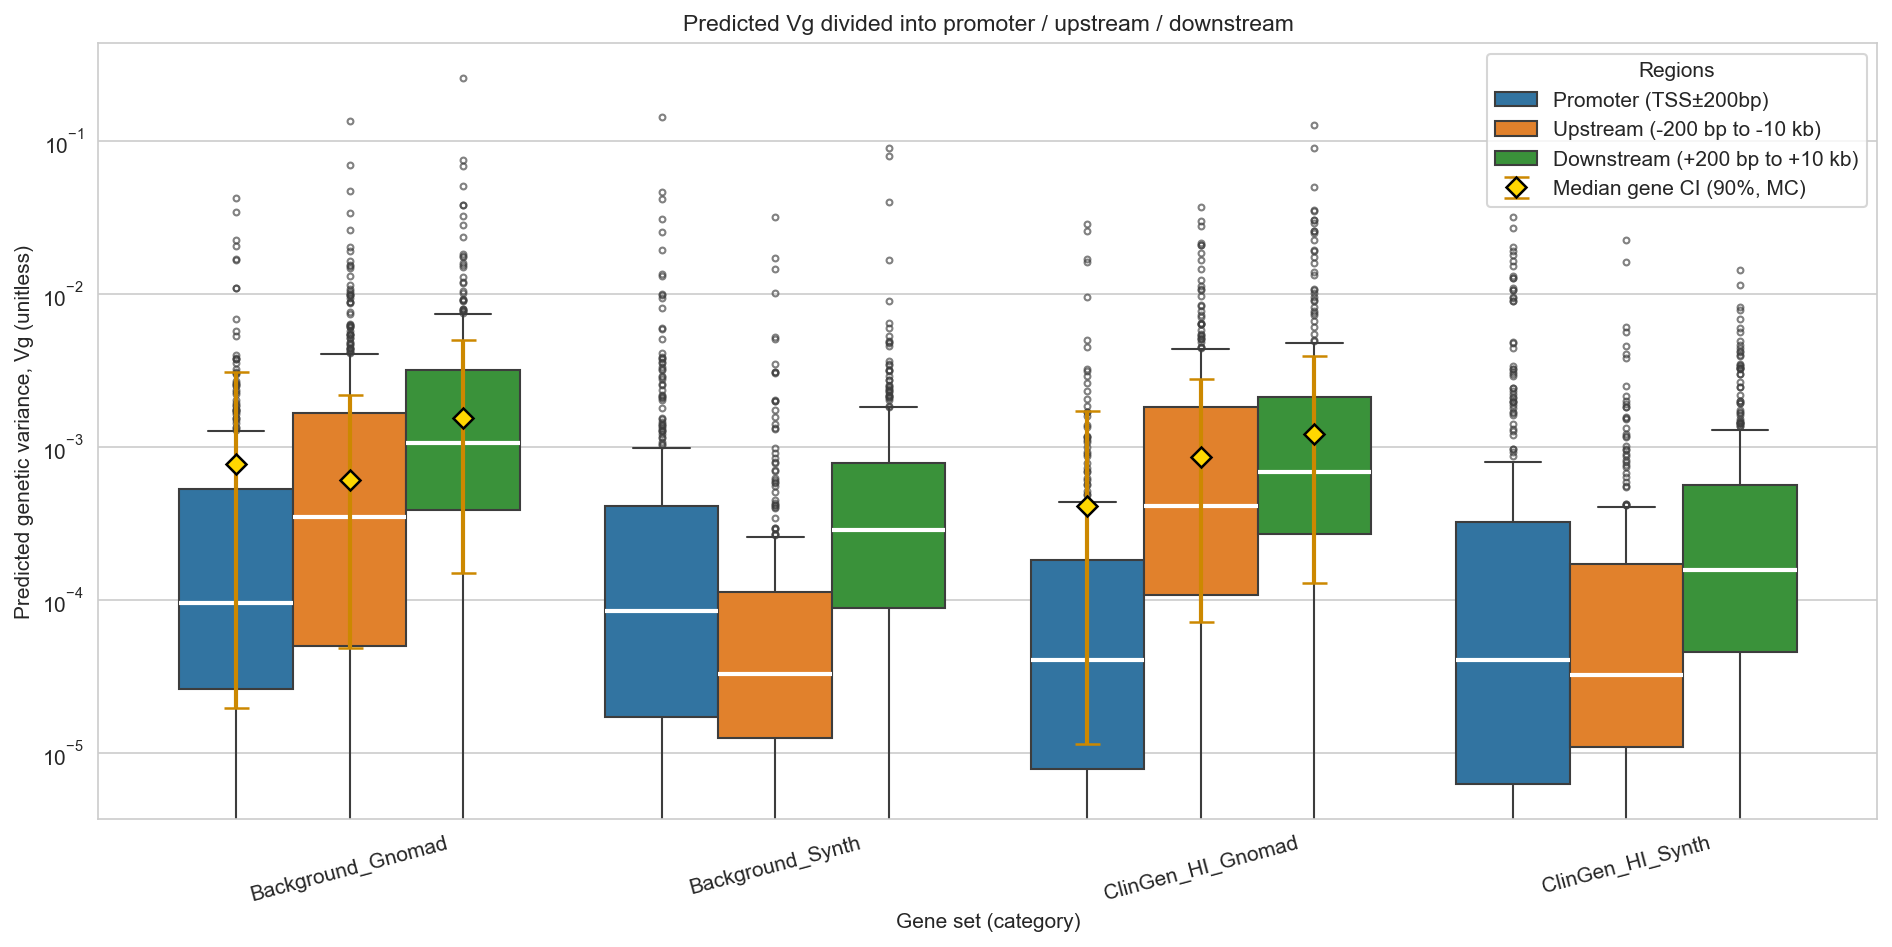

In [16]:

# 3b) Regional Vg summary collapsed to Promoter / Upstream / Downstream
region_3_df = plot_df.copy()
region_3_df['vg_upstream_total'] = region_3_df['vg_region_proximal_upstream'] + region_3_df['vg_region_distal_upstream']
region_3_df['vg_downstream_total'] = region_3_df['vg_region_down_proximal'] + region_3_df['vg_region_down_distal']

region_3_long = region_3_df.melt(
    id_vars=['source_label'],
    value_vars=[
        'vg_region_promoter_core',
        'vg_upstream_total',
        'vg_downstream_total',
    ],
    var_name='region_group',
    value_name='region_vg',
)

region_3_labels = {
    'vg_region_promoter_core': 'Promoter (TSS±200bp)',
    'vg_upstream_total': 'Upstream (-200 bp to -10 kb)',
    'vg_downstream_total': 'Downstream (+200 bp to +10 kb)',
}
region_3_order = [
    'Promoter (TSS±200bp)',
    'Upstream (-200 bp to -10 kb)',
    'Downstream (+200 bp to +10 kb)',
]
region_3_long['region_group'] = region_3_long['region_group'].map(region_3_labels)

# ── Build per-gene CI data for real datasets (per AGENTS.md: CIs on real only) ───
# CI columns used:
#   Promoter:   vg_promoter_core_CI_{p05,mean,p95}
#   Upstream:   per-gene sum of vg_proximal_upstream_CI_* + vg_distal_upstream_CI_*
#   Downstream: per-gene sum of vg_down_proximal_CI_*   + vg_down_distal_CI_*
# All CI columns are from the real (gnomAD) dataframes (df_bg, df_hi).

def _region3_ci(df_src):
    """Returns dict: region_label -> (med_p05, med_mean, med_p95)"""
    ci_data = {}

    # Promoter
    promo_cols = ['vg_promoter_core_CI_p05', 'vg_promoter_core_CI_mean', 'vg_promoter_core_CI_p95']
    if all(c in df_src.columns for c in promo_cols):
        ci_pd = df_src.select(promo_cols).to_pandas().dropna()
        ci_data['Promoter (TSS±200bp)'] = (
            ci_pd['vg_promoter_core_CI_p05'].median(),
            ci_pd['vg_promoter_core_CI_mean'].median(),
            ci_pd['vg_promoter_core_CI_p95'].median(),
        )

    # Upstream = proximal_upstream + distal_upstream, summed per gene
    up_cols = [
        'vg_proximal_upstream_CI_p05', 'vg_proximal_upstream_CI_mean', 'vg_proximal_upstream_CI_p95',
        'vg_distal_upstream_CI_p05',   'vg_distal_upstream_CI_mean',   'vg_distal_upstream_CI_p95',
    ]
    if all(c in df_src.columns for c in up_cols):
        ci_pd = df_src.select(up_cols).to_pandas().dropna()
        ci_data['Upstream (-200 bp to -10 kb)'] = (
            (ci_pd['vg_proximal_upstream_CI_p05'] + ci_pd['vg_distal_upstream_CI_p05']).median(),
            (ci_pd['vg_proximal_upstream_CI_mean'] + ci_pd['vg_distal_upstream_CI_mean']).median(),
            (ci_pd['vg_proximal_upstream_CI_p95'] + ci_pd['vg_distal_upstream_CI_p95']).median(),
        )

    # Downstream = down_proximal + down_distal, summed per gene
    dn_cols = [
        'vg_down_proximal_CI_p05', 'vg_down_proximal_CI_mean', 'vg_down_proximal_CI_p95',
        'vg_down_distal_CI_p05',   'vg_down_distal_CI_mean',   'vg_down_distal_CI_p95',
    ]
    if all(c in df_src.columns for c in dn_cols):
        ci_pd = df_src.select(dn_cols).to_pandas().dropna()
        ci_data['Downstream (+200 bp to +10 kb)'] = (
            (ci_pd['vg_down_proximal_CI_p05'] + ci_pd['vg_down_distal_CI_p05']).median(),
            (ci_pd['vg_down_proximal_CI_mean'] + ci_pd['vg_down_distal_CI_mean']).median(),
            (ci_pd['vg_down_proximal_CI_p95'] + ci_pd['vg_down_distal_CI_p95']).median(),
        )

    return ci_data

ci_bg_r3 = _region3_ci(df_bg)
ci_hi_r3 = _region3_ci(df_hi)
CI_REAL_R3 = {
    'Background_Gnomad': ci_bg_r3,
    'ClinGen_HI_Gnomad': ci_hi_r3,
}

CI_COLOR  = '#FFD700'
CI_ECOLOR = '#CC8800'

with autosave('AF_Cutoff_Regional_Promoter_Upstream_Downstream_Boxplot'):
    fig, ax = plt.subplots(figsize=(12.5, 6.2), constrained_layout=True)
    sns.boxplot(
        data=region_3_long,
        x='source_label',
        y='region_vg',
        hue='region_group',
        order=source_label_order,
        hue_order=region_3_order,
        showfliers=True,
        flierprops={'marker': 'o', 'markersize': 2.8, 'alpha': 0.65},
        medianprops={'color': 'white', 'linewidth': 2.0},
        ax=ax,
    )
    ax.set_yscale('log')

    # ── Overlay Monte Carlo CIs (real datasets only) ──────────────────────────
    # Hue offsets: with seaborn default width=0.8 and 3 hue groups,
    # offset_i = (i - (n-1)/2) * (0.8/n)
    n_hues = len(region_3_order)
    hue_offsets = [(i - (n_hues - 1) / 2) * (0.8 / n_hues) for i in range(n_hues)]

    ci_legend_added = False
    for src_label, ci_dict in CI_REAL_R3.items():
        if src_label not in source_label_order:
            continue
        x_base = source_label_order.index(src_label)
        for hue_idx, region_label in enumerate(region_3_order):
            if region_label not in ci_dict:
                print(f'  [skip CI] {src_label} / {region_label}: CI columns not found')
                continue
            med_p05, med_mean, med_p95 = ci_dict[region_label]
            x_pos = x_base + hue_offsets[hue_idx]
            label_ci = 'Median gene CI (90%, MC)' if not ci_legend_added else '_nolegend_'
            ax.errorbar(
                x_pos, med_mean,
                yerr=[[med_mean - med_p05], [med_p95 - med_mean]],
                fmt='D',
                color=CI_COLOR,
                ecolor=CI_ECOLOR,
                elinewidth=2.0,
                capsize=6,
                capthick=2.0,
                markersize=7,
                markeredgecolor='black',
                markeredgewidth=1.2,
                zorder=15,
                label=label_ci,
            )
            ci_legend_added = True
            print(
                f'{src_label} / {region_label}: '
                f'median CI = [{med_p05:.3e}, {med_p95:.3e}]  (mean={med_mean:.3e})'
            )

    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Predicted genetic variance, Vg (unitless)', fontsize=10)
    ax.set_title('Predicted Vg divided into promoter / upstream / downstream', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels_leg, title='Regions', frameon=True)


Median obs/perm ratios per region (all gene sets combined):
  Promoter (TSS±200bp): median=1.11  n=644
  Upstream (-200bp to -10kb): median=7.24  n=648
  Downstream (+200bp to +10kb): median=4.27  n=647

Promoter ratio < Upstream ratio:   p=1.03e-53  ****
Promoter ratio < Downstream ratio: p=1.01e-32  ****
Upstream vs Downstream (two-sided): p=6.12e-10  ****


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_88202/3903732272.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


[save_plot] Saved: figuree_AF_Cutoff_Regional_ObsPermRatio_Violin_14032026_1352.pdf
[save_plot] Saved: figuree_AF_Cutoff_Regional_ObsPermRatio_Violin_14032026_1352.svg


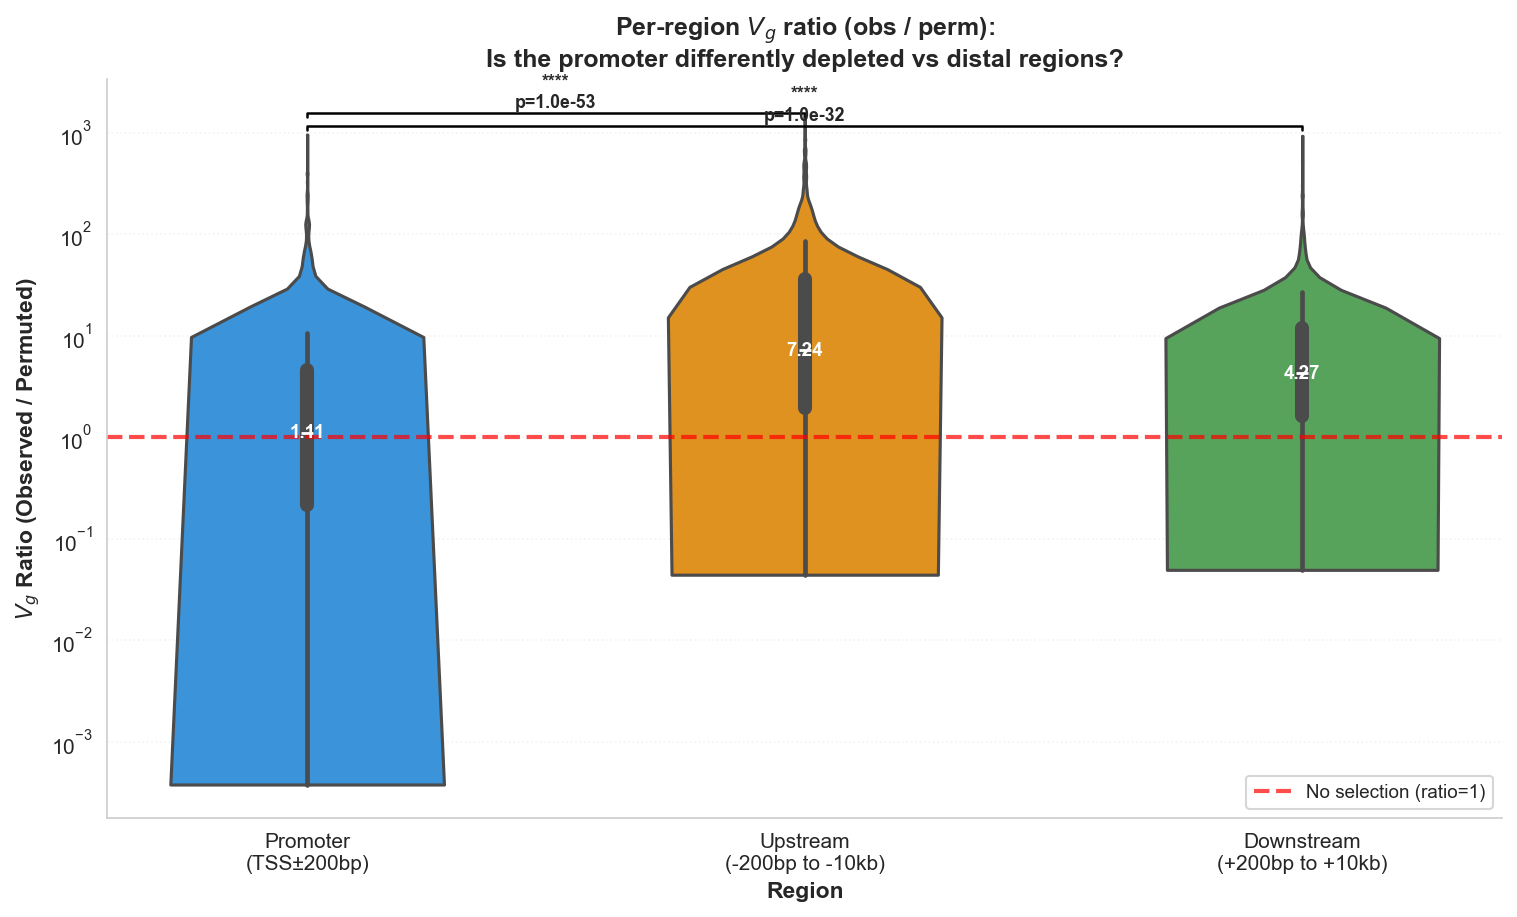

In [17]:

# Per-region obs/perm ratio — is the promoter ratio lower than distal regions?
# ─────────────────────────────────────────────────────────────────────────────
# region_3_df already has vg_upstream_total / vg_downstream_total / vg_region_promoter_core
# and uses the correct obs vs perm columns (via is_synth logic in plot_df)

perm_label_map = {
    'Background_Synth':  'Background_Gnomad',
    'ClinGen_HI_Synth': 'ClinGen_HI_Gnomad',
}

region_cols_3 = ['vg_region_promoter_core', 'vg_upstream_total', 'vg_downstream_total']

obs_reg = (
    region_3_df[region_3_df['source_label'].isin(['Background_Gnomad', 'ClinGen_HI_Gnomad'])]
    [['source_label', 'gene_symbol'] + region_cols_3]
    .copy()
)

perm_reg = (
    region_3_df[region_3_df['source_label'].isin(['Background_Synth', 'ClinGen_HI_Synth'])]
    [['source_label', 'gene_symbol'] + region_cols_3]
    .copy()
)
perm_reg['source_label'] = perm_reg['source_label'].map(perm_label_map)
perm_reg = perm_reg.rename(columns={c: c + '_perm' for c in region_cols_3})

merged_ratio = obs_reg.merge(perm_reg, on=['source_label', 'gene_symbol'], how='inner')

ratio_col_map = {
    'vg_region_promoter_core': 'ratio_promoter',
    'vg_upstream_total':       'ratio_upstream',
    'vg_downstream_total':     'ratio_downstream',
}
for obs_col, ratio_col in ratio_col_map.items():
    perm_col = obs_col + '_perm'
    merged_ratio[ratio_col] = np.where(
        merged_ratio[perm_col] > 0,
        merged_ratio[obs_col] / merged_ratio[perm_col],
        np.nan,
    )

ratio_label_map = {
    'ratio_promoter':   'Promoter\n(TSS±200bp)',
    'ratio_upstream':   'Upstream\n(-200bp to -10kb)',
    'ratio_downstream': 'Downstream\n(+200bp to +10kb)',
}
ratio_long = merged_ratio.melt(
    id_vars=['source_label', 'gene_symbol'],
    value_vars=list(ratio_col_map.values()),
    var_name='region', value_name='ratio',
)
ratio_long['region'] = ratio_long['region'].map(ratio_label_map)
ratio_long = ratio_long.dropna(subset=['ratio'])
ratio_long = ratio_long[ratio_long['ratio'] > 0].copy()

region_ratio_order = [
    'Promoter\n(TSS±200bp)',
    'Upstream\n(-200bp to -10kb)',
    'Downstream\n(+200bp to +10kb)',
]

# ── Statistics ──────────────────────────────────────────────────────────────
promo = ratio_long[ratio_long['region'] == 'Promoter\n(TSS±200bp)']['ratio']
up    = ratio_long[ratio_long['region'] == 'Upstream\n(-200bp to -10kb)']['ratio']
dn    = ratio_long[ratio_long['region'] == 'Downstream\n(+200bp to +10kb)']['ratio']

_, p_promo_vs_up = stats.mannwhitneyu(promo, up, alternative='less')
_, p_promo_vs_dn = stats.mannwhitneyu(promo, dn, alternative='less')
_, p_up_vs_dn    = stats.mannwhitneyu(up, dn, alternative='two-sided')

print('Median obs/perm ratios per region (all gene sets combined):')
for reg in region_ratio_order:
    sub = ratio_long[ratio_long['region'] == reg]['ratio']
    print(f'  {reg.replace(chr(10), " ")}: median={sub.median():.2f}  n={len(sub)}')

print(f'\nPromoter ratio < Upstream ratio:   p={p_promo_vs_up:.2e}  {p_to_stars(p_promo_vs_up)}')
print(f'Promoter ratio < Downstream ratio: p={p_promo_vs_dn:.2e}  {p_to_stars(p_promo_vs_dn)}')
print(f'Upstream vs Downstream (two-sided): p={p_up_vs_dn:.2e}  {p_to_stars(p_up_vs_dn)}')

# ── Plot ─────────────────────────────────────────────────────────────────────
region_color_map = {
    'Promoter\n(TSS±200bp)':       '#2196F3',
    'Upstream\n(-200bp to -10kb)': '#FF9800',
    'Downstream\n(+200bp to +10kb)': '#4CAF50',
}

with autosave('AF_Cutoff_Regional_ObsPermRatio_Violin'):
    fig, ax = plt.subplots(figsize=(10, 6.0), constrained_layout=True)

    sns.violinplot(
        data=ratio_long,
        x='region',
        y='ratio',
        order=region_ratio_order,
        palette=region_color_map,
        inner='box',
        cut=0,
        bw_adjust=0.8,
        linewidth=1.5,
        width=0.55,
        ax=ax,
    )

    # Median labels
    for i, reg in enumerate(region_ratio_order):
        med = ratio_long[ratio_long['region'] == reg]['ratio'].median()
        ax.text(i, med, f'{med:.2f}', ha='center', va='center',
                fontsize=9, color='white', weight='bold')

    # Significance brackets
    y_top = ax.get_ylim()[1]
    brackets = [
        (0, 1, p_promo_vs_up,  0),
        (0, 2, p_promo_vs_dn,  1),
    ]
    for x1, x2, p, level in brackets:
        y = y_top * (0.75 ** level)
        ax.plot([x1, x1, x2, x2],
                [y / 1.10, y, y, y / 1.10], 'k-', lw=1.2)
        ax.text((x1 + x2) / 2, y * 1.03,
                f'{p_to_stars(p)}\np={p:.1e}',
                ha='center', va='bottom', fontsize=8.5, weight='bold')

    ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7,
               label='No selection (ratio=1)')
    ax.set_yscale('log')
    ax.set_xlabel('Region', fontsize=11, weight='bold')
    ax.set_ylabel(r'$V_g$ Ratio (Observed / Permuted)', fontsize=11, weight='bold')
    ax.set_title(
        'Per-region $V_g$ ratio (obs / perm):\nIs the promoter differently depleted vs distal regions?',
        fontsize=12, weight='bold',
    )
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    sns.despine()


# 4. Rare fraction summary

[save_plot] Saved: figuree_AF_Cutoff_Rare_Fraction_of_Total_Vg_14032026_1352.pdf
[save_plot] Saved: figuree_AF_Cutoff_Rare_Fraction_of_Total_Vg_14032026_1352.svg
Plot 4 complete.


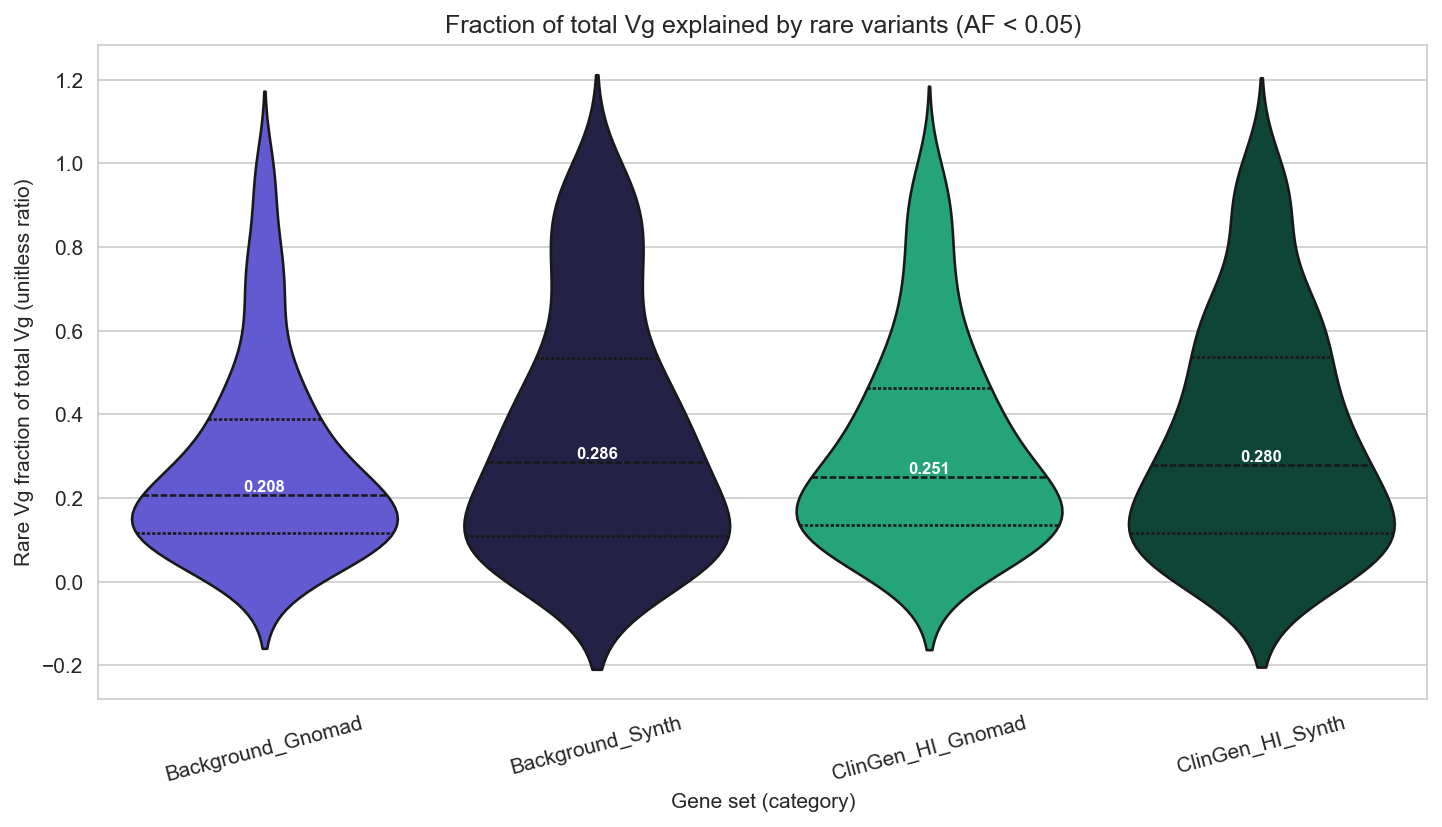

In [18]:
# 4) Rare fraction summary
with autosave('AF_Cutoff_Rare_Fraction_of_Total_Vg'):
    fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
    sns.violinplot(
        data=plot_df,
        x='source_label',
        y='vg_rare_fraction',
        hue='source_label',
        order=source_label_order,
        hue_order=source_label_order,
        palette=palette_by_label,
        legend=False,
        inner='quart',
        cut=2,
        bw_adjust=1.2,
        ax=ax,
    )
    annotate_medians(ax, plot_df, 'source_label', 'vg_rare_fraction', source_label_order, fmt='{:.3f}', text_color='white')
    ax.set_xlabel('Gene set (category)', fontsize=10)
    ax.set_ylabel('Rare Vg fraction of total Vg (unitless ratio)', fontsize=10)
    ax.set_title('Fraction of total Vg explained by rare variants (AF < 0.05)')
    ax.tick_params(axis='x', rotation=15)

print('Plot 4 complete.')